In [6]:
import esoreader
import pandas as pd
import os
import matplotlib.pyplot as plt


# Beizaee Table 6 reference values
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# Room name mapping between model and Beizaee paper
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

def process_eso_variable_by_day(variable_name, eso, timesteps_per_hour=6):
    df = eso.to_frame(variable_name).copy()
    total_timesteps = df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps // timesteps_per_day

    daily_dfs = {}
    for day in range(total_days):
        start = day * timesteps_per_day
        end = (day + 1) * timesteps_per_day
        day_df = df.iloc[start:end].copy()

        time_index = pd.date_range(start="00:00", periods=timesteps_per_day, freq=f"{60 // timesteps_per_hour}min").strftime('%H:%M')
        day_df.index = time_index

        daily_dfs[f"Day {day + 1}"] = day_df

    df.index = range(len(df))
    return df, daily_dfs

def calculate_energy_per_day(gas_df, timesteps_per_hour=6):
    """
    Dynamically calculates average daily gas energy in kWh/day.

    Arguments:
        gas_df: DataFrame of gas values per timestep (MJ)
        timesteps_per_hour: Number of timesteps per hour in the simulation

    Returns:
        Average daily gas energy use in kWh/day
    """
    total_mj = gas_df.sum().sum()
    total_timesteps = gas_df.shape[0]
    timesteps_per_day = timesteps_per_hour * 24
    total_days = total_timesteps / timesteps_per_day

    total_mj = total_mj / 10**6

    total_kwh = total_mj * 0.277777778  # MJ to TWh to kWh
    kwh_per_day = total_kwh / total_days
    return kwh_per_day


def load_simulations(experiment_names, base_path="/workspaces/CUBES/exp/jack/beizaee_validation", run='beizaee', timesteps_per_hour=6):
    """
    Loads Zone Air Temperature and Gas data for each experiment,
    returns one combined DataFrame per experiment (indexed by logical timestep).

    Returns:
        A dictionary: {experiment_name: DataFrame (temps + gas)}
    """
    combined_dfs = {}

    for exp in experiment_names:
        eso_path = os.path.join(base_path, run, exp, "eplusout.eso")
        if not os.path.exists(eso_path):
            print(f"⚠️ Missing ESO file for: {exp}")
            continue

        eso = esoreader.read_from_path(eso_path)

        # Get zone air temps
        df_temp = eso.to_frame("Zone Air Temperature").copy()

        # Get gas consumption
        df_gas = eso.to_frame("Gas").copy()
        df_gas.columns = ["Gas"]  # Ensure standard column name

        # Combine both into one DataFrame
        df_combined = pd.concat([df_temp, df_gas], axis=1)

        # Create a timestep index (00:00 to 23:50 repeated over days)
        timesteps_per_day = timesteps_per_hour * 24
        total_timesteps = df_combined.shape[0]
        total_days = total_timesteps // timesteps_per_day
        # Create a time index with arbitrary starting date (e.g., 2000-01-01)
        time_index = pd.date_range(
            start="2000-01-01 00:00",
            periods=total_timesteps,
            freq=f"{60 // timesteps_per_hour}min"
        )
        df_combined.index = time_index

        df_combined.index = time_index

        combined_dfs[exp] = df_combined

    return combined_dfs



def plot_simulation_day(sim_data, day="Day 2", variable="temp", rooms=None, experiments=None):
    """
    Plot one day's worth of data from multiple experiments.

    Arguments:
        sim_data: dict of {experiment_name: DataFrame with zone temps + Gas}
        day: e.g. "Day 2" (logical day)
        variable: "temp" or "gas"
        rooms: list of rooms to include (only for temp)
        experiments: subset of sim_data keys to plot (defaults to all)
    """
    if experiments is None:
        experiments = list(sim_data.keys())

    if variable == "temp":
        if rooms is None:
            rooms = [
                "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
                "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
            ]

        nrows = len(rooms)
        ncols = len(experiments)
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True, sharey=True)

        # Ensure axes is 2D array
        if nrows == 1 and ncols == 1:
            axes = [[axes]]
        elif nrows == 1:
            axes = [axes]
        elif ncols == 1:
            axes = [[ax] for ax in axes]

        for i, room in enumerate(rooms):
            for j, exp in enumerate(experiments):
                ax = axes[i][j]
                df = sim_data[exp]
                # Filter by day
                day_df = df[df.index.floor("D") == df.index.floor("D").unique()[int(day.split(" ")[1]) - 1]]
                day_df[room].plot(ax=ax, label="Air Temp", linestyle="-")

                ax.set_ylim(10, 25)
                ax.set_ylabel("Temp (°C)")
                ax.set_title(f"{room} – {exp.replace('_', ' ').title()}", fontsize=10)
                ax.grid(True)

                if i == nrows - 1:
                    ax.set_xlabel("Time")

                if i == 0 and j == ncols - 1:
                    ax.legend(loc="upper right")

        plt.tight_layout()
        plt.subplots_adjust(top=0.95)
        plt.show()

    elif variable == "gas":
        fig, ax = plt.subplots(figsize=(8, 4))
        for exp in experiments:
            df = sim_data[exp]
            day_df = df[df.index.floor("D") == df.index.floor("D").unique()[int(day.split(" ")[1]) - 1]]
            day_df["Gas"].plot(ax=ax, label=exp.replace("_", " ").title())

        ax.set_ylabel("Gas Consumption (MJ)")
        ax.set_title(f"Gas Use – {day}")
        ax.grid(True)
        ax.legend()
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("Invalid variable. Choose 'temp' or 'gas'.")



def plot_daily_gas_comparison(sim_data, variable="Gas"):
    """
    Plots daily gas consumption for each experiment in sim_data.

    Parameters:
    - sim_data (dict): Dictionary of {experiment_name: DataFrame}
    - variable (str): Column name containing gas consumption (default = 'Gas')
    """
    daily_usage = {}

    for exp, df in sim_data.items():
        if variable not in df.columns:
            print(f"⚠️ Missing '{variable}' in: {exp}")
            continue

        # Group by day and sum gas usage
        daily_gas = df[variable].resample("D").sum()
        daily_usage[exp] = daily_gas

    # Combine into a single DataFrame
    daily_df = pd.DataFrame(daily_usage)

    # Plot
    plt.figure(figsize=(12, 6))
    for exp in daily_df.columns:
        plt.plot(daily_df.index, daily_df[exp], label=exp, marker='o')

    plt.title("Daily Gas Consumption by Experiment")
    plt.xlabel("Day")
    plt.ylabel("Total Gas Consumption (kWh)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return daily_df  # Optional: return it for inspection


def compare_with_beizaee_from_combined_data(sim_data, room_mapping):
    """
    sim_data: dict of {experiment_name: combined_df with temps + gas}
    room_mapping: mapping from E+ zones to Beizaee room names
    """
    sim_results = {}
    energy_use = {}

    for label, df in sim_data.items():
        # Get average temps over entire simulation for each zone
        mean_temps = df.mean()

        # Extract relevant zone temps
        zone_temps = mean_temps.loc[room_mapping.keys()]
        df_zone = zone_temps.to_frame(name=f"Simulated_{label}")
        df_zone["Beizaee Room"] = df_zone.index.map(room_mapping)
        df_grouped = df_zone.groupby("Beizaee Room").mean()

        # Add whole house average
        df_grouped.loc["Whole House"] = df_grouped[f"Simulated_{label}"].mean()

        sim_results[label] = df_grouped
        energy_use[label] = calculate_energy_per_day(df["Gas"].to_frame())

    # Start with Beizaee reference
    df = beizaee_df.copy()

    # Join simulated results
    for label, result_df in sim_results.items():
        df = df.join(result_df)

        # Compare with Beizaee if relevant
        if label.upper() in df.columns:  # e.g., "ZC", "CC"
            df[f"Diff_{label}"] = df[f"Simulated_{label}"] - df[label]

    # Compare simulations
    labels = list(sim_results.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            col_name = f"Simulated_Diff_{labels[i]}_vs_{labels[j]}"
            df[col_name] = df[f"Simulated_{labels[i]}"] - df[f"Simulated_{labels[j]}"]

    return df.round(2), energy_use


In [8]:
experiments = ["conventional_control", "zonal_control", "occupancy_control"]
# experiments = ["occupancy_control"]
beizaee_sim_data = load_simulations(experiments, run='beizaee')
lynch_sim_data = load_simulations(experiments, run='lynch')




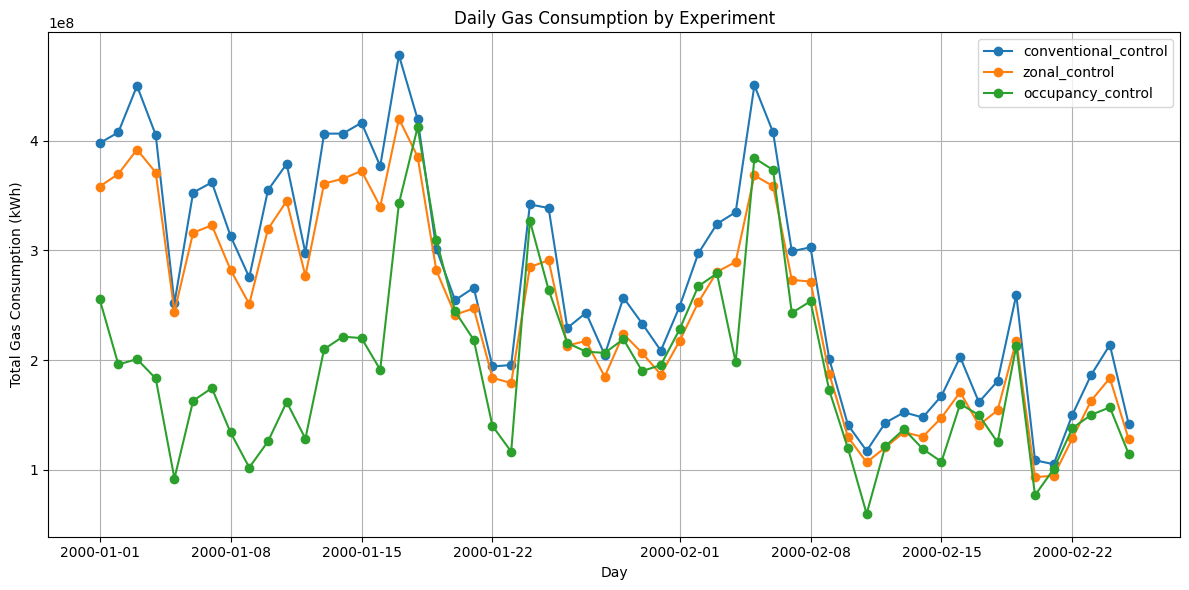

In [ ]:
daily_df = plot_daily_gas_comparison(beizaee_sim_data)


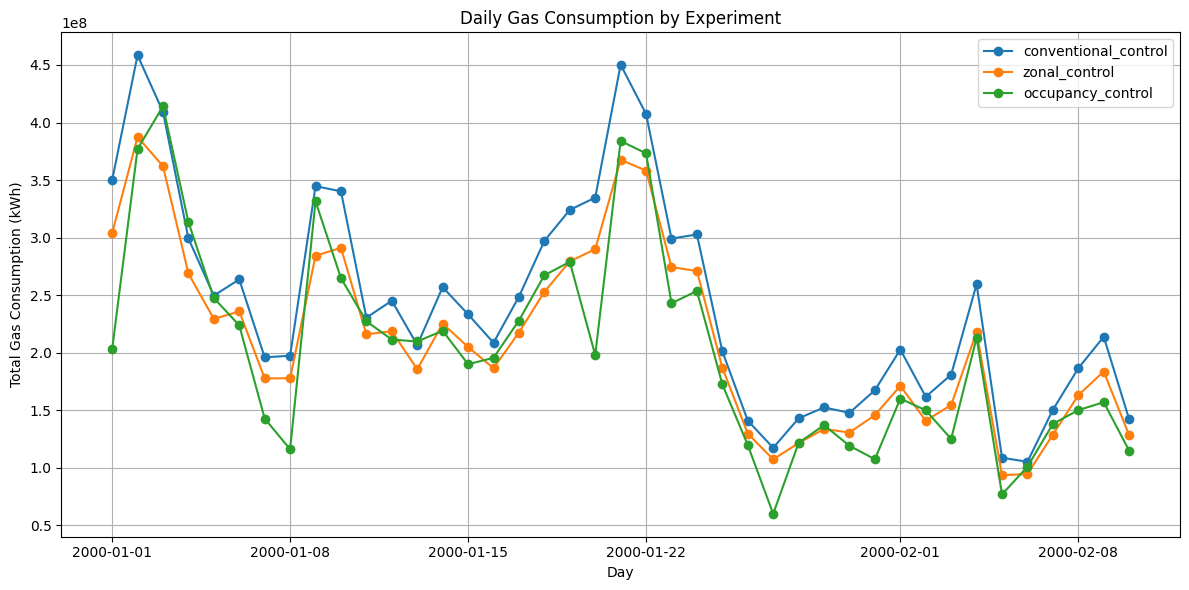

In [9]:
daily_df = plot_daily_gas_comparison(lynch_sim_data)

In [10]:
beizaee_comparison_df, beizaee_energy_dict = compare_with_beizaee_from_combined_data(beizaee_sim_data, room_mapping)
lynch_comparison_df, lynch_energy_dict = compare_with_beizaee_from_combined_data(lynch_sim_data, room_mapping)

In [11]:
beizaee_energy_dict

{'conventional_control': 76.70257146202182,
 'zonal_control': 68.33927238613985,
 'occupancy_control': 53.676064036951225}

In [12]:
lynch_energy_dict

{'conventional_control': 67.31998076643637,
 'zonal_control': 58.93740793545927,
 'occupancy_control': 56.48784561633722}

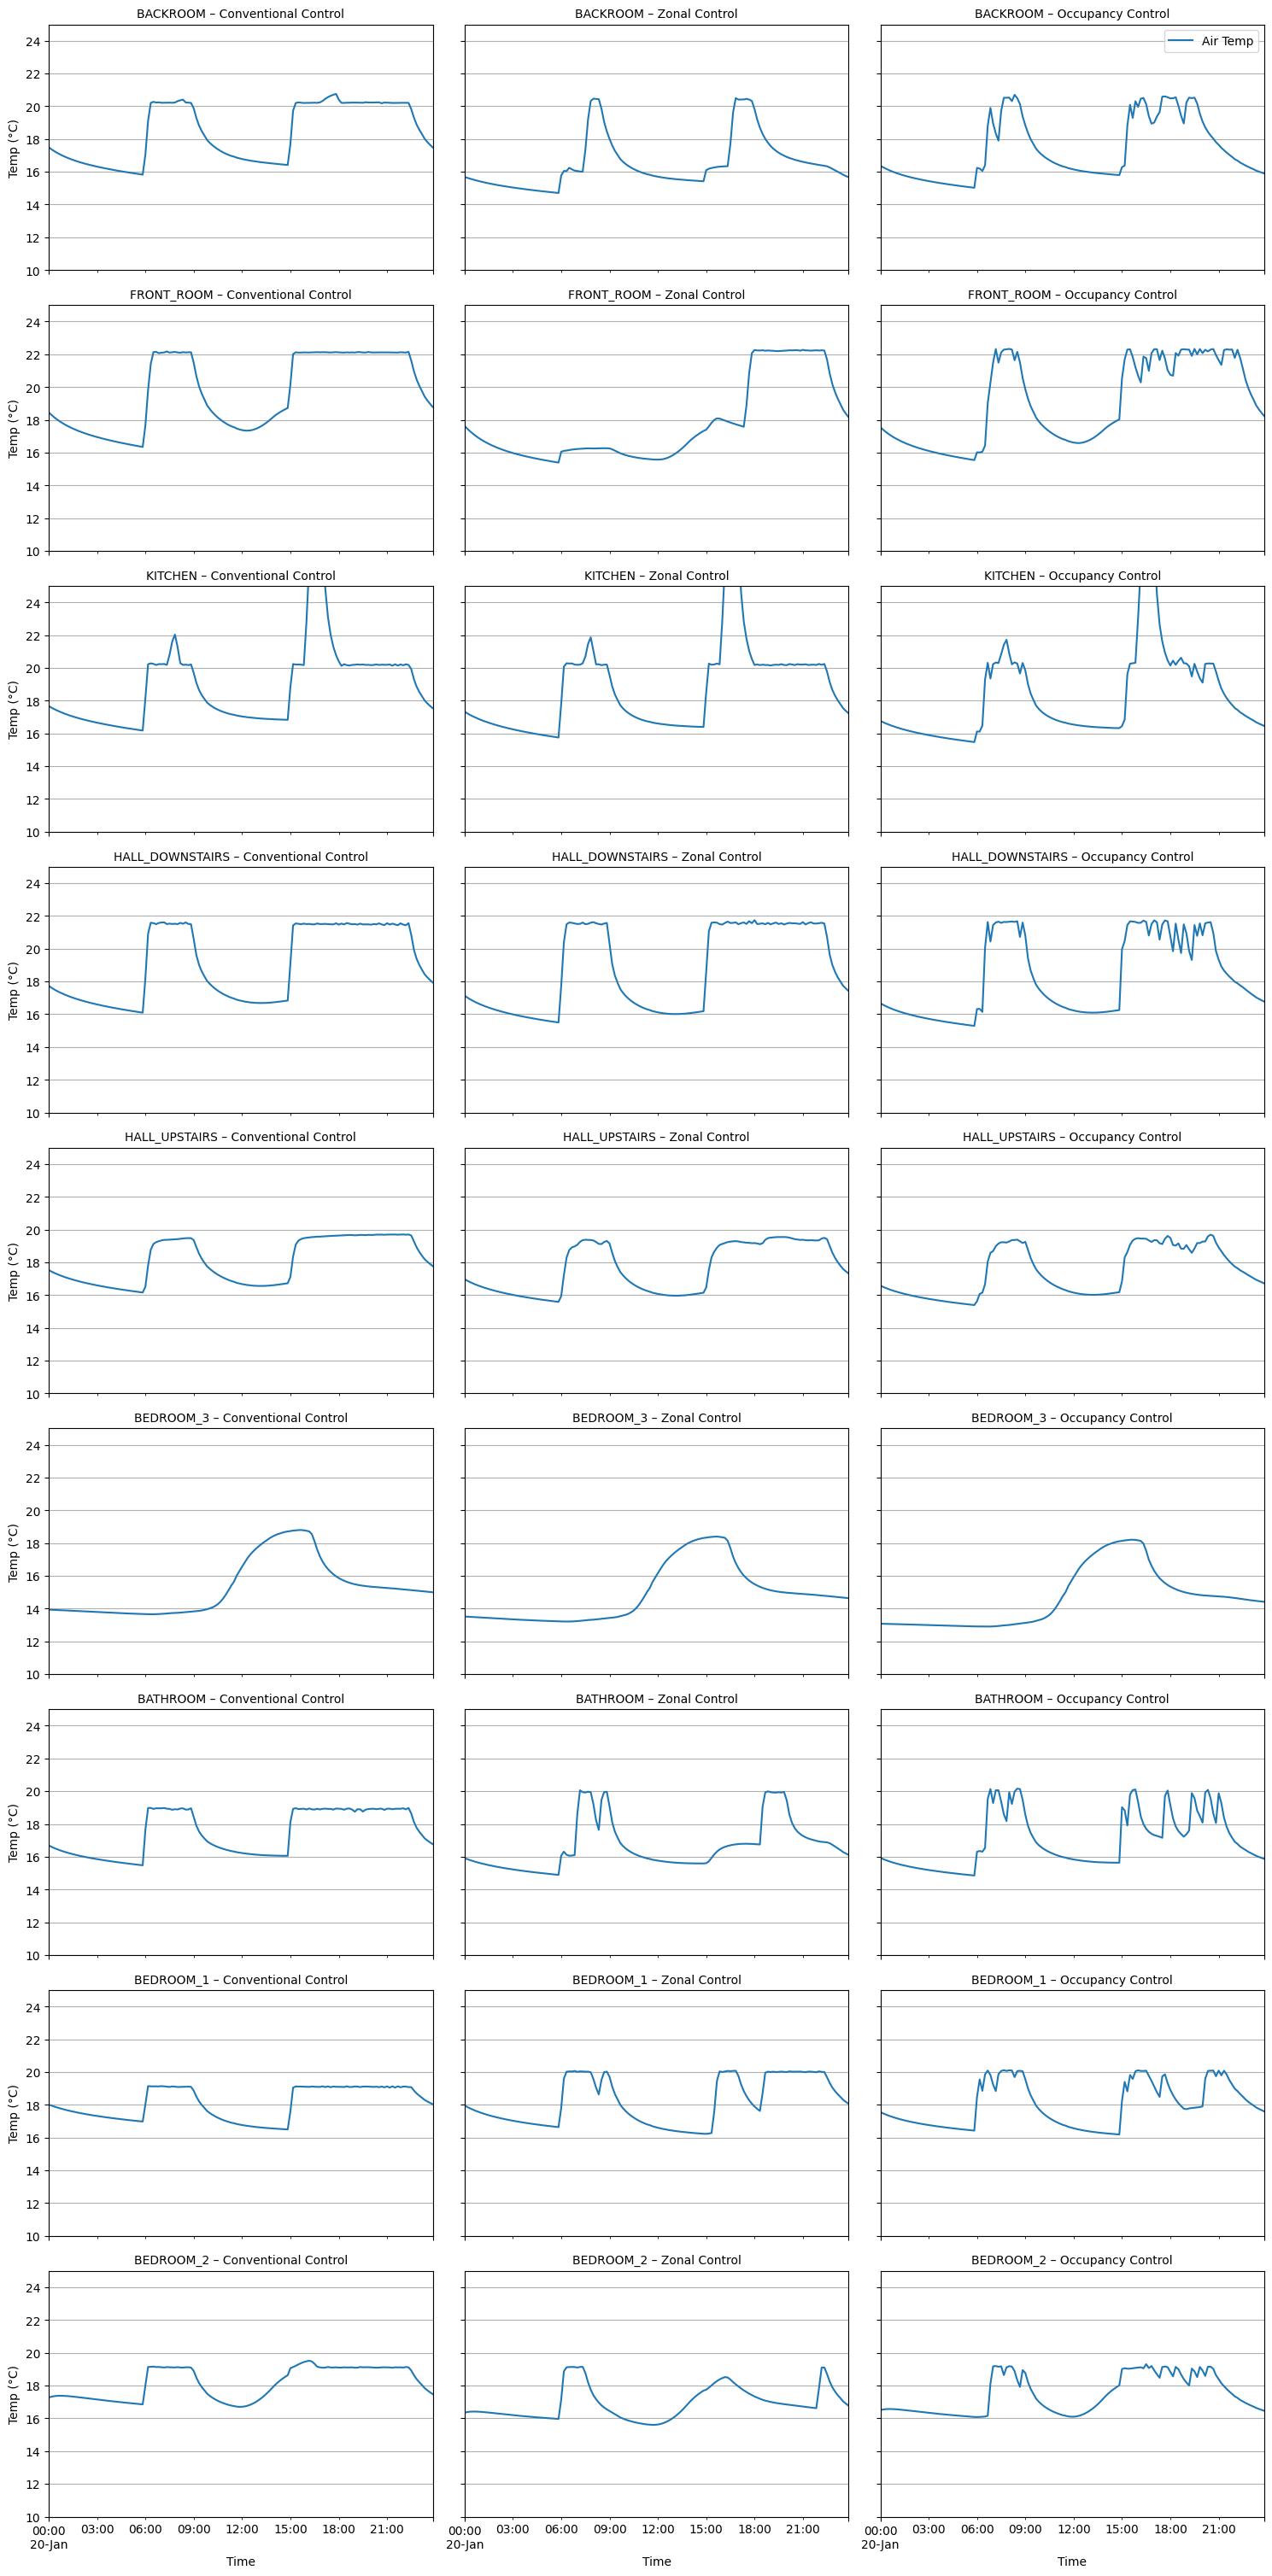

In [7]:
plot_simulation_day(sim_data, day="Day 20", variable="temp", experiments=experiments)

In [3]:
comparison_df, energy_dict = compare_with_beizaee_from_combined_data(sim_data, room_mapping)
cols_to_keep = [
    "CC",
    "ZC",
    "Simulated_conventional_control",
    "Simulated_zonal_control"
]

summary_df = comparison_df[cols_to_keep].copy()

# Calculate differences
summary_df["Beizaee_Diff"] = summary_df["CC"] - summary_df["ZC"]
summary_df["Simulated_Diff"] = summary_df["Simulated_conventional_control"] - summary_df["Simulated_zonal_control"]

summary_df = summary_df.round(2)  # optional: round to 2 decimal places

summary_df


,CC,ZC,Simulated_conventional_control,Simulated_zonal_control,Beizaee_Diff,Simulated_Diff
Room,,,,,,
Living Room,20.0,19.2,20.23,18.15,0.8,2.08
Dining Room,18.7,18.2,18.73,16.94,0.5,1.79
Bedroom 1,18.3,18.0,18.34,18.39,0.3,-0.05
Bedroom 2,18.2,17.2,18.53,17.45,1.0,1.08
Bathroom,17.7,16.5,17.64,16.75,1.2,0.89
Unoccupied Room,15.3,14.8,15.71,15.42,0.5,0.29
Circulation Areas,19.5,19.1,18.94,18.58,0.4,0.36
Kitchen,20.0,19.6,19.16,18.93,0.4,0.23
Whole House,18.7,18.1,18.41,17.58,0.6,0.83


In [6]:
energy_dict

{'conventional_control': 76.07621816497833,
 'zonal_control': 66.20394762787782,
 'occupancy_control': 52.44703484561374}

In [15]:
print(calculate_energy_per_day(sim_data["conventional_control"]["Gas"]))
print(calculate_energy_per_day(sim_data["zonal_control"]["Gas"]))
print(calculate_energy_per_day(sim_data["occupancy_control"]["Gas"]))

70.02853003526592
60.915550805057194
55.24775482056596


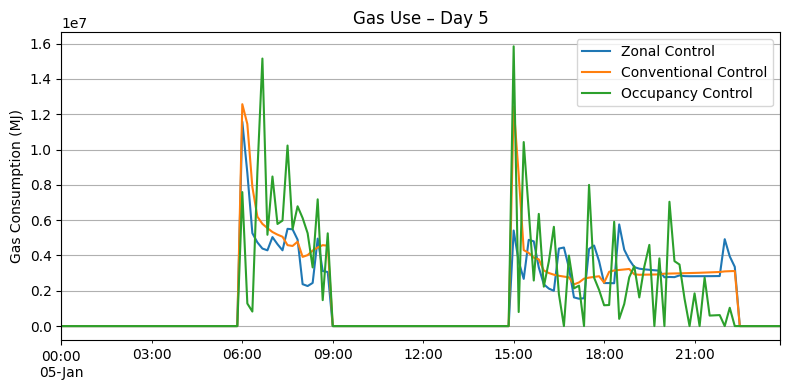

In [19]:
plot_simulation_day(sim_data, day="Day 5", variable="gas")

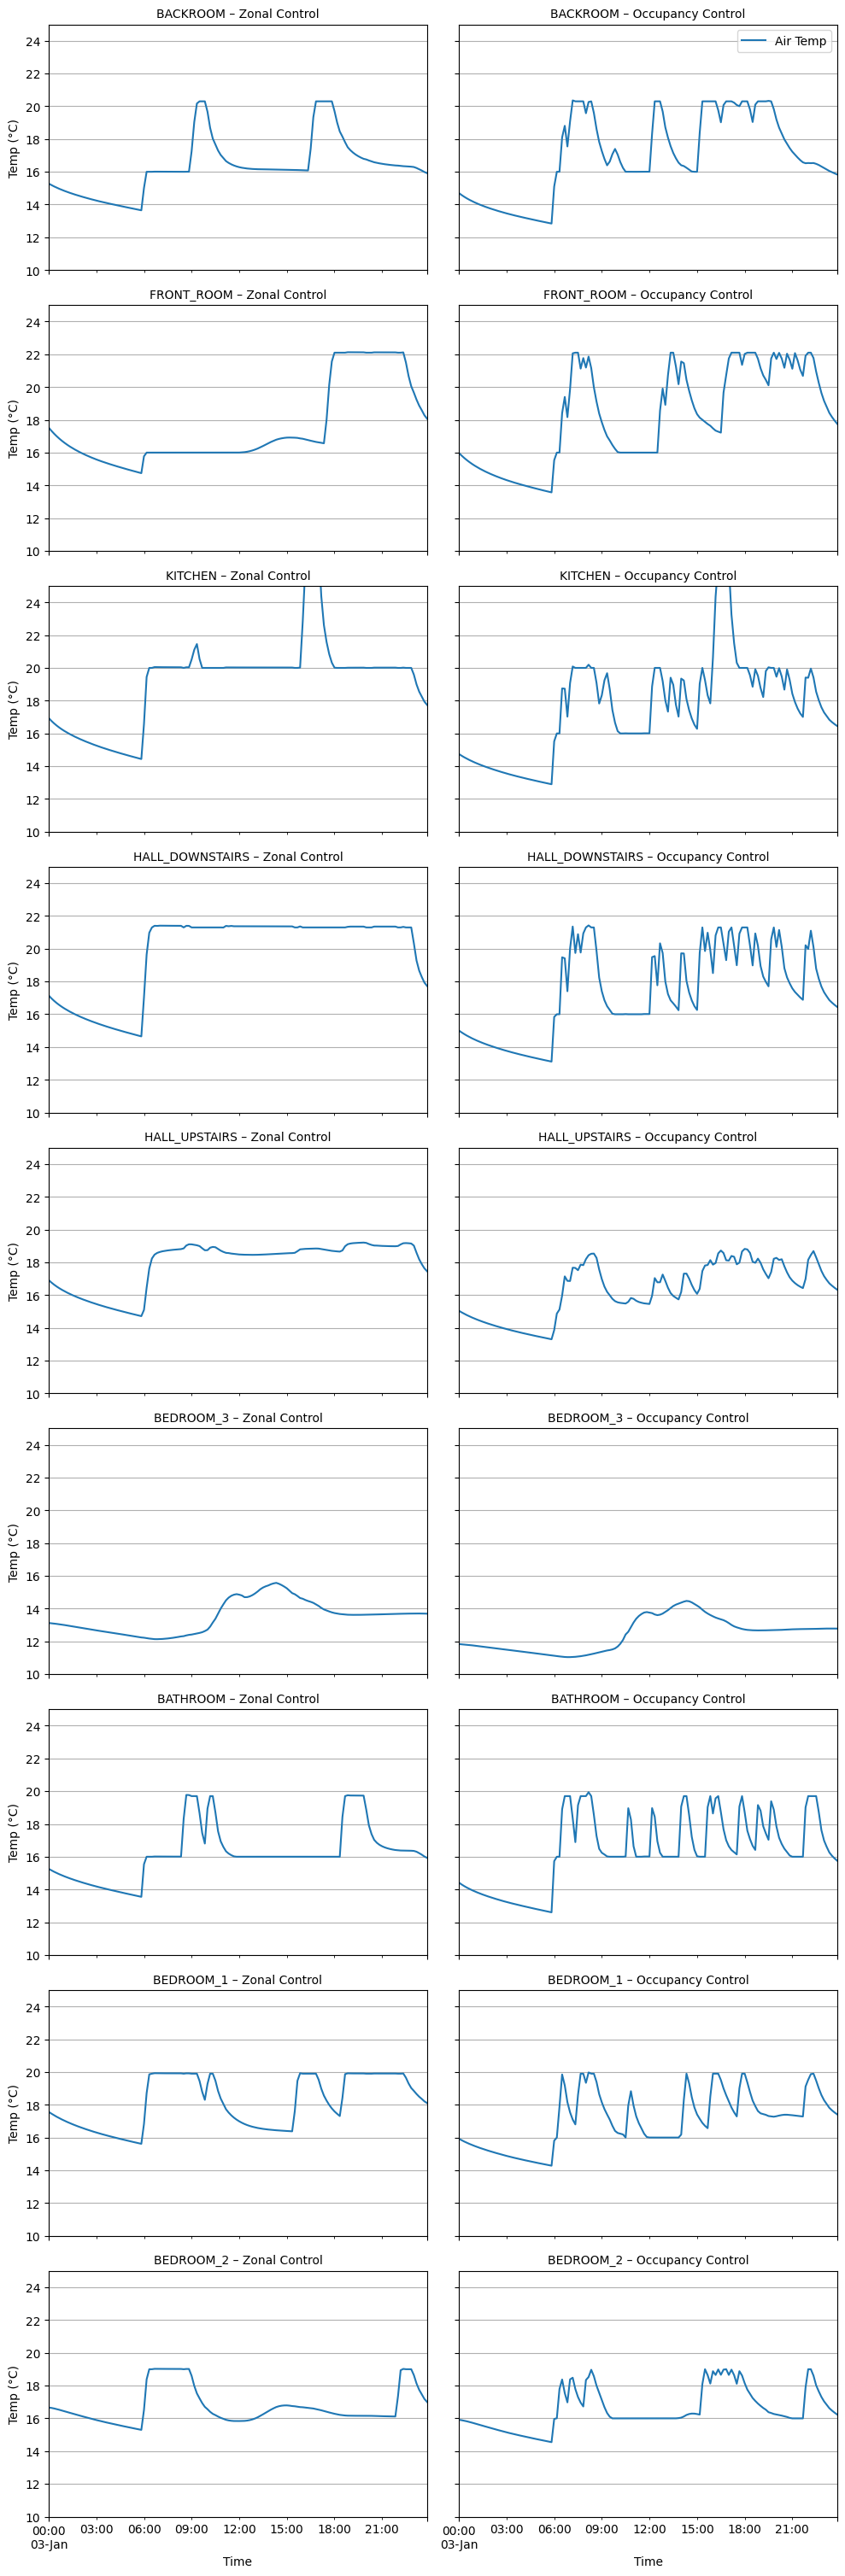

In [13]:
# Assume sim_data is already loaded via load_simulations()
# plot_simulation_day(sim_data, day="Day 2", variable="temp")
# plot_simulation_day(sim_data, day="Day 2", variable="gas")
plot_simulation_day(sim_data, day="Day 3", variable="temp", experiments=["zonal_control", "occupancy_control"])


In [1]:
import os
# from pathlib import Path
# from eppy import modeleditor
# from eppy.modeleditor import IDF
import esoreader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [9]:
oc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/occupancy_control/eplusout.eso"

eso = esoreader.read_from_path(oc_path)

In [10]:
eso

In [2]:
# import pandas as pd

# # Load occupancy data
# df = pd.read_csv('/workspaces/CUBES/cubes/data/occupants/rep_0.sch')
# df['UTC_Time'] = pd.to_datetime(df['UTC_Time'])
# df.set_index('UTC_Time', inplace=True)

# # Thermostat values for each room
# rooms = {
#     "BACKROOM": 20.3,
#     "FRONT_ROOM": 22.1,
#     "KITCHEN": 20.0,
#     "HALL_DOWNSTAIRS": 21.3,
#     "HALL_UPSTAIRS": 12.0,
#     "BEDROOM_3": 12.0,
#     "BATHROOM": 19.7,
#     "BEDROOM_1": 19.9,
#     "BEDROOM_2": 19.0
# }

# # Create a dictionary to store schedules
# room_schedules = {}

# for room, setpoint in rooms.items():
#     # Get occupancy series for the room
#     room_occ = df[[room.lower()]]

#     # Determine if any occupancy > 0 in each 10-minute window
#     occ_10min = room_occ.resample('10T').max()

#     # Apply setpoint logic
#     occ_10min['heating_setpoint'] = occ_10min[room.lower()].apply(
#         lambda occ: setpoint if occ > 0 else 16
#     )

#     # Store the heating schedule only
#     room_schedules[room.lower()] = occ_10min[['heating_setpoint']]

# for room, schedule_df in room_schedules.items():
#     out_path = f"/workspaces/CUBES/exp/jack/beizaee_validation/building_model-external/{room.lower()}_heating_schedule.sch"
#     schedule_df.to_csv(out_path, index=False, header=True)






In [3]:



def plot_eso_data(daily_temp, daily_setpoint, period_name, room, plot_type, start_day=None, num_days=1, time_slot=None):
    """
    A unified function to plot room temperature and setpoint temperature.

    Parameters:
    - daily_temp: Dictionary of DataFrames containing daily temperature data.
    - daily_setpoint: Dictionary of DataFrames containing daily setpoint temperature data.
    - period_name: The validation period (e.g., "16th Feb – 15th Mar").
    - room: The name of the room (e.g., "BACKROOM").
    - plot_type: Type of plot - "consecutive_days" (plot multiple days as a continuous series)
                                      or "single_timeslot" (plot a specific timeslot across all days).
    - start_day: The starting day number (e.g., 4 for "Day 4").
    - num_days: The number of consecutive days to plot.
    - time_slot: Specific time of day (e.g., "06:00") to extract across multiple days (for "single_timeslot" plot).
    """

    # Check if the period and room exist in data
    if period_name not in daily_temp or period_name not in daily_setpoint:
        raise ValueError(f"Period '{period_name}' not found in data.")
    if start_day is None or start_day < 1:
        raise ValueError("Please provide a valid start_day (>= 1).")

    if plot_type == "consecutive_days":
        # Collect data for consecutive days
        temp_list = []
        setpoint_list = []
        for day in range(start_day, start_day + num_days):
            day_name = f"Day {day}"
            if day_name in daily_temp[period_name] and day_name in daily_setpoint[period_name]:
                temp_list.append(daily_temp[period_name][day_name][room])
                setpoint_list.append(daily_setpoint[period_name][day_name][room])

        if not temp_list or not setpoint_list:
            raise ValueError("No valid data found for the specified days.")

        # Concatenate all days into a single DataFrame
        temp_series = pd.concat(temp_list)
        setpoint_series = pd.concat(setpoint_list)

        # Plot the concatenated time series
        plt.figure(figsize=(12, 5))
        temp_series.plot(label="Actual Temp", linestyle="-")
        plt.xlabel("Time (HH:MM)")
        plt.ylabel("Temperature (°C)")
        plt.xticks(rotation=45)  # Rotate x-axis labels for readability
        plt.title(f"Temperature vs. Setpoint in {room} ({period_name}, Days {start_day}-{start_day + num_days - 1})")
        plt.legend()
        plt.grid()
        plt.show()

    elif plot_type == "single_timeslot":
        if time_slot is None:
            raise ValueError("Please provide a time_slot for 'single_timeslot' plot.")

        # Extract the specified time slot from each day
        timeslot_temp = []
        timeslot_setpoint = []
        days = []

        for day in daily_temp[period_name]:
            if time_slot in daily_temp[period_name][day].index:
                timeslot_temp.append(daily_temp[period_name][day].loc[time_slot, room])
                timeslot_setpoint.append(daily_setpoint[period_name][day].loc[time_slot, room])
                days.append(day)

        if not timeslot_temp or not timeslot_setpoint:
            raise ValueError(f"No data found for time slot '{time_slot}'.")

        # Plot the extracted values across days
        plt.figure(figsize=(12, 5))
        plt.plot(days, timeslot_temp, marker="o", linestyle="-", label="Actual Temp")
        plt.plot(days, timeslot_setpoint, marker="s", linestyle="--", label="Setpoint Temp")
        plt.xlabel("Day")
        plt.ylabel("Temperature (°C)")
        plt.xticks(rotation=45)
        plt.title(f"Temperature vs. Setpoint in {room} at {time_slot} ({period_name})")
        plt.legend()
        plt.grid()
        plt.show()

    else:
        raise ValueError("Invalid plot_type. Choose 'consecutive_days' or 'single_timeslot'.")


def process_eso_variable(variable_name, eso):
    """
    Process any variable from ESO, split by validation period and day.
    Returns:
        - split_dfs: Full DataFrames for each period
        - daily_dfs: DataFrames split by day
    """

    # Define the number of timesteps per hour and per day
    timesteps_per_hour = 6  # Adjust based on your EnergyPlus settings
    timesteps_per_day = timesteps_per_hour * 24

    # Define the simulation start date for each period
    start_dates = {
        "16th Feb – 15th Mar": "2014-02-16",
        "18th Mar – 8th Apr": "2014-03-18",
        "16th Apr – 21st Apr": "2014-04-16",
    }

    # Define start and end indices for each validation period
    periods = {
        "16th Feb – 15th Mar": (0, 28 * timesteps_per_day),  # First 28 days
        "18th Mar – 8th Apr": (30 * timesteps_per_day, 52 * timesteps_per_day),  # Days 30-52
        "16th Apr – 21st Apr": (59 * timesteps_per_day, 64 * timesteps_per_day),  # Days 59-64
    }

    # Extract variable data into a DataFrame
    df = eso.to_frame(variable_name)

    # Create separate DataFrames for each run period
    split_dfs = {}
    daily_dfs = {}

    for period, (start_idx, end_idx) in periods.items():
        # Extract full period DataFrame
        period_df = df.iloc[start_idx:end_idx].copy()

        # Generate timestamps based on EnergyPlus timesteps
        start_date = pd.Timestamp(start_dates[period])
        timestamps = pd.date_range(start=start_date, periods=len(period_df), freq=f"{60//timesteps_per_hour}min")

        # Assign timestamps as index
        period_df.index = timestamps

        # Create a dictionary to store daily data
        daily_data = {}

        # Split by day
        num_days = (end_idx - start_idx) // timesteps_per_day
        for day in range(num_days):
            day_start = start_date + pd.Timedelta(days=day)
            day_end = day_start + pd.Timedelta(hours=23, minutes=59)
            daily_df = period_df.loc[day_start:day_end].copy()

            # Format x-axis to display only hours (HH:MM)
            daily_df.index = daily_df.index.strftime('%H:%M')

            daily_data[f"Day {day + 1}"] = daily_df

        # Store both full period and daily data
        split_dfs[period] = period_df
        daily_dfs[period] = daily_data  # Dictionary of DataFrames split by day

    return split_dfs, daily_dfs


# Helper function
def get_processed_variables(eso_path):
    eso = esoreader.read_from_path(eso_path)
    split_temp, daily_temp = process_eso_variable("Zone Air Temperature", eso=eso)
    split_setpoint, daily_setpoint = process_eso_variable("Zone Thermostat Heating Setpoint Temperature", eso=eso)
    return daily_temp, daily_setpoint


def plot_data():

    # 🔹 Define layout
    rooms = [
        "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
        "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
    ]
    days = ["Day 2", "Day 3"]
    period_name = "16th Feb – 15th Mar"

    fig, axes = plt.subplots(nrows=len(rooms), ncols=3, figsize=(14, 30), sharex=True, sharey=True)

    # 🔹 Plot both simulations
    for i, room in enumerate(rooms):
        for j, (label, daily_temp, daily_setpoint) in enumerate([
            ("Conventional", daily_temp_cc, daily_setpoint_cc),
            ("Zonal", daily_temp_zc, daily_setpoint_zc),
            ("Occupancy", daily_temp_oc, daily_setpoint_oc),
        ]):
            ax = axes[i, j]
            temp_series = daily_temp[period_name][days[i % 2]][room]
            setpoint_series = daily_setpoint[period_name][days[i % 2]][room]

            temp_series.plot(ax=ax, label="Actual Temp", linestyle="-")
            setpoint_series.plot(ax=ax, label="Setpoint", linestyle="--")

            ax.set_ylim(10, 25)
            ax.set_ylabel("Temp (°C)")
            ax.set_title(f"{room} – {label}", fontsize=10)
            ax.grid(True)

            if i == len(rooms) - 1:
                ax.set_xlabel("Hour of Day")

            if i == 0 and j == 1:
                ax.legend(loc="upper right")

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()



def plot_all_zones():
    # 🔹 Load both simulations
    cc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso"
    zc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso"
    oc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/occupancy_control/eplusout.eso"

    daily_temp_cc, daily_setpoint_cc = get_processed_variables(cc_path)
    daily_temp_zc, daily_setpoint_zc = get_processed_variables(zc_path)
    daily_temp_oc, daily_setpoint_oc = get_processed_variables(oc_path)

    plot_data()







In [8]:
import matplotlib.pyplot as plt

def get_eso_path(exp_name):
    base_path = "/workspaces/CUBES/exp/jack/beizaee_validation"
    return f"{base_path}/{exp_name}/eplusout.eso"

def plot_data(daily_data, day_to_plot, period_name):
    rooms = [
        "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
        "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
    ]

    experiments = list(daily_data.keys())
    nrows = len(rooms)
    ncols = len(experiments)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 3.5 * nrows), sharex=True, sharey=True)

    # Ensure axes is 2D array even if ncols or nrows == 1
    if nrows == 1 and ncols == 1:
        axes = [[axes]]
    elif nrows == 1:
        axes = [axes]
    elif ncols == 1:
        axes = [[ax] for ax in axes]

    for i, room in enumerate(rooms):
        for j, exp_name in enumerate(experiments):
            ax = axes[i][j]
            daily_temp, daily_setpoint = daily_data[exp_name]
            temp_series = daily_temp[period_name][day_to_plot][room]
            setpoint_series = daily_setpoint[period_name][day_to_plot][room]

            temp_series.plot(ax=ax, label="Actual Temp", linestyle="-")
            setpoint_series.plot(ax=ax, label="Setpoint", linestyle="--")

            ax.set_ylim(10, 25)
            ax.set_ylabel("Temp (°C)")
            ax.set_title(f"{room} – {exp_name.replace('_', ' ').title()}", fontsize=10)
            ax.grid(True)

            if i == nrows - 1:
                ax.set_xlabel("Hour of Day")

            if i == 0 and j == ncols - 1:
                ax.legend(loc="upper right")

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

def plot_all_zones(experiments=["conventional_control", "zonal_control", "occupancy_control"],
                   day="Day 2",
                   period_name="16th Feb – 15th Mar"):

    daily_data = {}

    for exp in experiments:
        path = get_eso_path(exp)
        daily_temp, daily_setpoint = get_processed_variables(path)
        daily_data[exp] = (daily_temp, daily_setpoint)

    plot_data(daily_data, day_to_plot=day, period_name=period_name)


In [6]:
plot_all_zones(
    experiments=["conventional_control", "zonal_control", "occupancy_control"],
    day="Day 1",
    period_name="16th Feb – 15th Mar"
)


TypeError: plot_all_zones() got an unexpected keyword argument 'experiments'

In [9]:
# from eppy.modeleditor import IDF
# import os

# # Load IDD first
# iddfile = "/usr/local/EnergyPlus-9-5-0/Energy+.idd"
# idf_path = "/workspaces/CUBES/exp/jack/beizaee_validation/building_model.idf"

# EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"
# iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
# IDF.setiddname(iddfile)
# idf = IDF(idf_path)



# def get_material_r_value(material):
#     # Thermal resistance R = thickness / conductivity
#     thickness = float(material.Thickness)
#     conductivity = float(material.Conductivity)
#     return thickness / conductivity if conductivity > 0 else 0


# u_values = {}

# for construction in idf.idfobjects["CONSTRUCTION"]:
#     r_total = 0
#     for i in range(1, 11):  # Up to 10 layers
#         field = f"Layer_{i}"
#         if hasattr(construction, field):
#             material_name = getattr(construction, field)
#             if not material_name:
#                 continue
#             material = idf.getobject("MATERIAL", material_name.upper())
#             if material:
#                 r_total += get_material_r_value(material)

#     if r_total > 0:
#         u_value = 1 / r_total
#         u_values[construction.Name] = round(u_value, 3)

# # Show results
# for name, u in u_values.items():
#     print(f"{name}: U = {u} W/m²K")


In [5]:

# Beizaee Table 6: Whole day average air temperatures (°C)
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7]
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

def calculate_energy_per_day(mj_total):
    return (mj_total/10**9) * 4.94642857143

def process_simulation(path_to_eso):
    eso = esoreader.read_from_path(path_to_eso)
    df_air_temp = eso.to_frame('Zone Air Temperature')
    df_gas = eso.to_frame("Gas")
    total_gas_mj = df_gas.sum().values[0] # Sum over time and meters
    gas_kwh_per_day = calculate_energy_per_day(total_gas_mj)

    mean_temps = df_air_temp.mean()
    df_sim = mean_temps.to_frame(name='Simulated Temp')
    df_filtered = df_sim.loc[room_mapping.keys()].copy()
    df_filtered['Beizaee Room'] = df_filtered.index.map(room_mapping)
    df_grouped = df_filtered.groupby('Beizaee Room').mean()
    df_grouped.loc['Whole House'] = df_grouped['Simulated Temp'].mean()

    return df_grouped, gas_kwh_per_day

# Run both simulations
cc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso"
zc_path = "/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso"

cc_results, cc_energy = process_simulation(cc_path)
zc_results, zc_energy = process_simulation(zc_path)

print(zc_energy, cc_energy)
print(f"Percentage reduction: {(1-(zc_energy/cc_energy))*100}")

cc_results = cc_results.rename(columns={"Simulated Temp": "Simulated_CC"})
zc_results = zc_results.rename(columns={"Simulated Temp": "Simulated_ZC"})

comparison_df = pd.concat([beizaee_df, cc_results, zc_results], axis=1)
comparison_df["Diff_CC"] = comparison_df["Simulated_CC"] - comparison_df["CC"]
comparison_df["Diff_ZC"] = comparison_df["Simulated_ZC"] - comparison_df["ZC"]
comparison_df["Beizaee_Diff"] = comparison_df["ZC"] - comparison_df["CC"]
comparison_df["Simulated_Diff"] = comparison_df["Simulated_ZC"] - comparison_df["Simulated_CC"]


# Reorder columns
comparison_df = comparison_df.reindex(columns=[
    "CC", "Simulated_CC", "Diff_CC",
    "ZC", "Simulated_ZC", "Diff_ZC",
    "Beizaee_Diff", "Simulated_Diff"
])

# Optional: sort by Diff_CC
comparison_df = comparison_df.sort_values(by="Diff_CC", ascending=False)

# Show result
comparison_df.round(2)


76.20109155823256 87.25044013051789
Percentage reduction: 12.663945941999389


,CC,Simulated_CC,Diff_CC,ZC,Simulated_ZC,Diff_ZC,Beizaee_Diff,Simulated_Diff
Unoccupied Room,15.3,15.64,0.34,14.8,15.38,0.58,-0.5,-0.26
Bedroom 2,18.2,18.42,0.22,17.2,17.38,0.18,-1.0,-1.04
Living Room,20.0,20.03,0.03,19.2,18.00,-1.20,-0.8,-2.04
Bedroom 1,18.3,18.24,-0.06,18.0,18.31,0.31,-0.3,0.08
Dining Room,18.7,18.54,-0.16,18.2,16.70,-1.50,-0.5,-1.84
Bathroom,17.7,17.46,-0.24,16.5,16.66,0.16,-1.2,-0.80
Whole House,18.7,18.26,-0.44,18.1,17.46,-0.64,-0.6,-0.80
Circulation Areas,19.5,18.76,-0.74,19.1,18.45,-0.65,-0.4,-0.31
Kitchen,20.0,18.99,-1.01,19.6,18.82,-0.78,-0.4,-0.17


In [4]:
import pandas as pd
import esoreader

# Beizaee Table 6 reference values
beizaee_data = {
    "Room": [
        "Living Room", "Dining Room", "Bedroom 1", "Bedroom 2", "Bathroom",
        "Unoccupied Room", "Circulation Areas", "Kitchen", "Whole House"
    ],
    "ZC": [19.2, 18.2, 18.0, 17.2, 16.5, 14.8, 19.1, 19.6, 18.1],
    "CC": [20.0, 18.7, 18.3, 18.2, 17.7, 15.3, 19.5, 20.0, 18.7]
}
beizaee_df = pd.DataFrame(beizaee_data).set_index("Room")

# Room name mapping between model and Beizaee paper
room_mapping = {
    'FRONT_ROOM': 'Living Room',
    'BACKROOM': 'Dining Room',
    'BEDROOM_1': 'Bedroom 1',
    'BEDROOM_2': 'Bedroom 2',
    'BEDROOM_3': 'Unoccupied Room',
    'BATHROOM': 'Bathroom',
    'KITCHEN': 'Kitchen',
    'HALL_DOWNSTAIRS': 'Circulation Areas',
    'HALL_UPSTAIRS': 'Circulation Areas',
}

def calculate_energy_per_day(mj_total):
    return (mj_total / 1e9) * 4.94642857143

def process_simulation(path_to_eso):
    eso = esoreader.read_from_path(path_to_eso)
    df_air_temp = eso.to_frame('Zone Air Temperature')
    df_gas = eso.to_frame("Gas")
    total_gas_mj = df_gas.sum().values[0]
    gas_kwh_per_day = calculate_energy_per_day(total_gas_mj)

    mean_temps = df_air_temp.mean()
    df_sim = mean_temps.to_frame(name='Simulated Temp')
    df_filtered = df_sim.loc[room_mapping.keys()].copy()
    df_filtered['Beizaee Room'] = df_filtered.index.map(room_mapping)
    df_grouped = df_filtered.groupby('Beizaee Room').mean()
    df_grouped.loc['Whole House'] = df_grouped['Simulated Temp'].mean()

    return df_grouped, gas_kwh_per_day

def compare_with_beizaee(simulations):
    """
    simulations: dict of {"name": "path_to_eso"}
    """
    sim_results = {}
    energy_use = {}

    for label, path in simulations.items():
        df_grouped, energy = process_simulation(path)
        sim_results[label] = df_grouped.rename(columns={"Simulated Temp": f"Simulated_{label}"})
        energy_use[label] = energy

    # Start with Beizaee reference
    df = beizaee_df.copy()

    # Merge in all simulated data
    for label, result_df in sim_results.items():
        df = df.join(result_df)

        # Compare with Beizaee if relevant data exists
        if label.upper() in df.columns:  # e.g., "ZC" or "CC"
            df[f"Diff_{label}"] = df[f"Simulated_{label}"] - df[label]

    # Compare simulated diffs if there are at least two simulations
    if len(sim_results) >= 2:
        labels = list(sim_results.keys())
        for i in range(len(labels)):
            for j in range(i + 1, len(labels)):
                col_name = f"Simulated_Diff_{labels[i]}_vs_{labels[j]}"
                df[col_name] = df[f"Simulated_{labels[i]}"] - df[f"Simulated_{labels[j]}"]

    return df.round(2), energy_use


In [ ]:
simulations = {
    "CC": "/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso",
    "ZC": "/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso",
    "OC": "/workspaces/CUBES/exp/jack/beizaee_validation/occupancy_control/eplusout.eso"
}

comparison_df, energy_dict = compare_with_beizaee(simulations)


print("\nEnergy use per day (kWh):")
for label, energy in energy_dict.items():
    print(f"{label}: {energy:.2f} kWh")

# Optional: compute percentage savings
if "CC" in energy_dict and "ZC" in energy_dict:
    savings = 100 * (1 - energy_dict["ZC"] / energy_dict["CC"])
    print(f"\nZonal vs Conventional Energy Reduction: {savings:.1f}%")


                     ZC    CC  Simulated_CC  Diff_CC  Simulated_ZC  Diff_ZC  \
Room                                                                          
Living Room        19.2  20.0         20.19     0.19         18.26    -0.94   
Dining Room        18.2  18.7         18.69    -0.01         16.98    -1.22   
Bedroom 1          18.0  18.3         18.39     0.09         18.51     0.51   
Bedroom 2          17.2  18.2         18.62     0.42         17.77     0.57   
Bathroom           16.5  17.7         17.61    -0.09         16.92     0.42   
Unoccupied Room    14.8  15.3         16.21     0.91         16.00     1.20   
Circulation Areas  19.1  19.5         18.93    -0.57         18.66    -0.44   
Kitchen            19.6  20.0         19.15    -0.85         19.00    -0.60   
Whole House        18.1  18.7         18.47    -0.23         17.76    -0.34   

                   Simulated_OC  Simulated_Diff_CC_vs_ZC  \
Room                                                       
Living Roo

In [7]:
comparison_df

,ZC,CC,Simulated_CC,Diff_CC,Simulated_ZC,Diff_ZC,Simulated_OC,Simulated_Diff_CC_vs_ZC,Simulated_Diff_CC_vs_OC,Simulated_Diff_ZC_vs_OC
Room,,,,,,,,,,
Living Room,19.2,20.0,20.19,0.19,18.26,-0.94,18.75,1.93,1.44,-0.49
Dining Room,18.2,18.7,18.69,-0.01,16.98,-1.22,17.40,1.71,1.29,-0.42
Bedroom 1,18.0,18.3,18.39,0.09,18.51,0.51,18.02,-0.12,0.37,0.49
Bedroom 2,17.2,18.2,18.62,0.42,17.77,0.57,17.84,0.85,0.78,-0.08
Bathroom,16.5,17.7,17.61,-0.09,16.92,0.42,16.98,0.69,0.62,-0.06
Unoccupied Room,14.8,15.3,16.21,0.91,16.00,1.20,15.64,0.22,0.57,0.36
Circulation Areas,19.1,19.5,18.93,-0.57,18.66,-0.44,17.66,0.27,1.26,1.00
Kitchen,19.6,20.0,19.15,-0.85,19.00,-0.60,18.15,0.16,1.01,0.85
Whole House,18.1,18.7,18.47,-0.23,17.76,-0.34,17.56,0.71,0.92,0.20


In [18]:


eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso")
# eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso")


# available_variables = eso.dd.variables
# for var_id, var_info in available_variables.items():
#     print(var_info)


df_baseboard_flow = eso.to_frame('Baseboard Heating Water Mass Flow Rate')
df_pump_flow = eso.to_frame('Pump Mass Flow Rate')
df_boiler_flow = eso.to_frame('Boiler Inlet Mass Flow Rate')
df_baseboard_heat = eso.to_frame('Baseboard Total Heating Rate')
df_boiler_heat = eso.to_frame('Boiler Heating Rate')

df_boiler_inlet = eso.to_frame('Boiler Inlet Temperature')
df_boiler_outlet = eso.to_frame('Boiler Outlet Temperature')

df_pump = eso.to_frame('Pump Mass Flow Rate')
df_plant_flow = eso.to_frame('Plant Supply Side Heating Demand Rate')








In [ ]:
eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso")
# eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso")

# 🔹 Example Usage - Process Different Variables
split_temp, daily_temp = process_eso_variable("Zone Air Temperature")
split_setpoint, daily_setpoint = process_eso_variable("Zone Thermostat Heating Setpoint Temperature")




NameError: name 'process_eso_variable' is not defined

NameError: name 'plt' is not defined

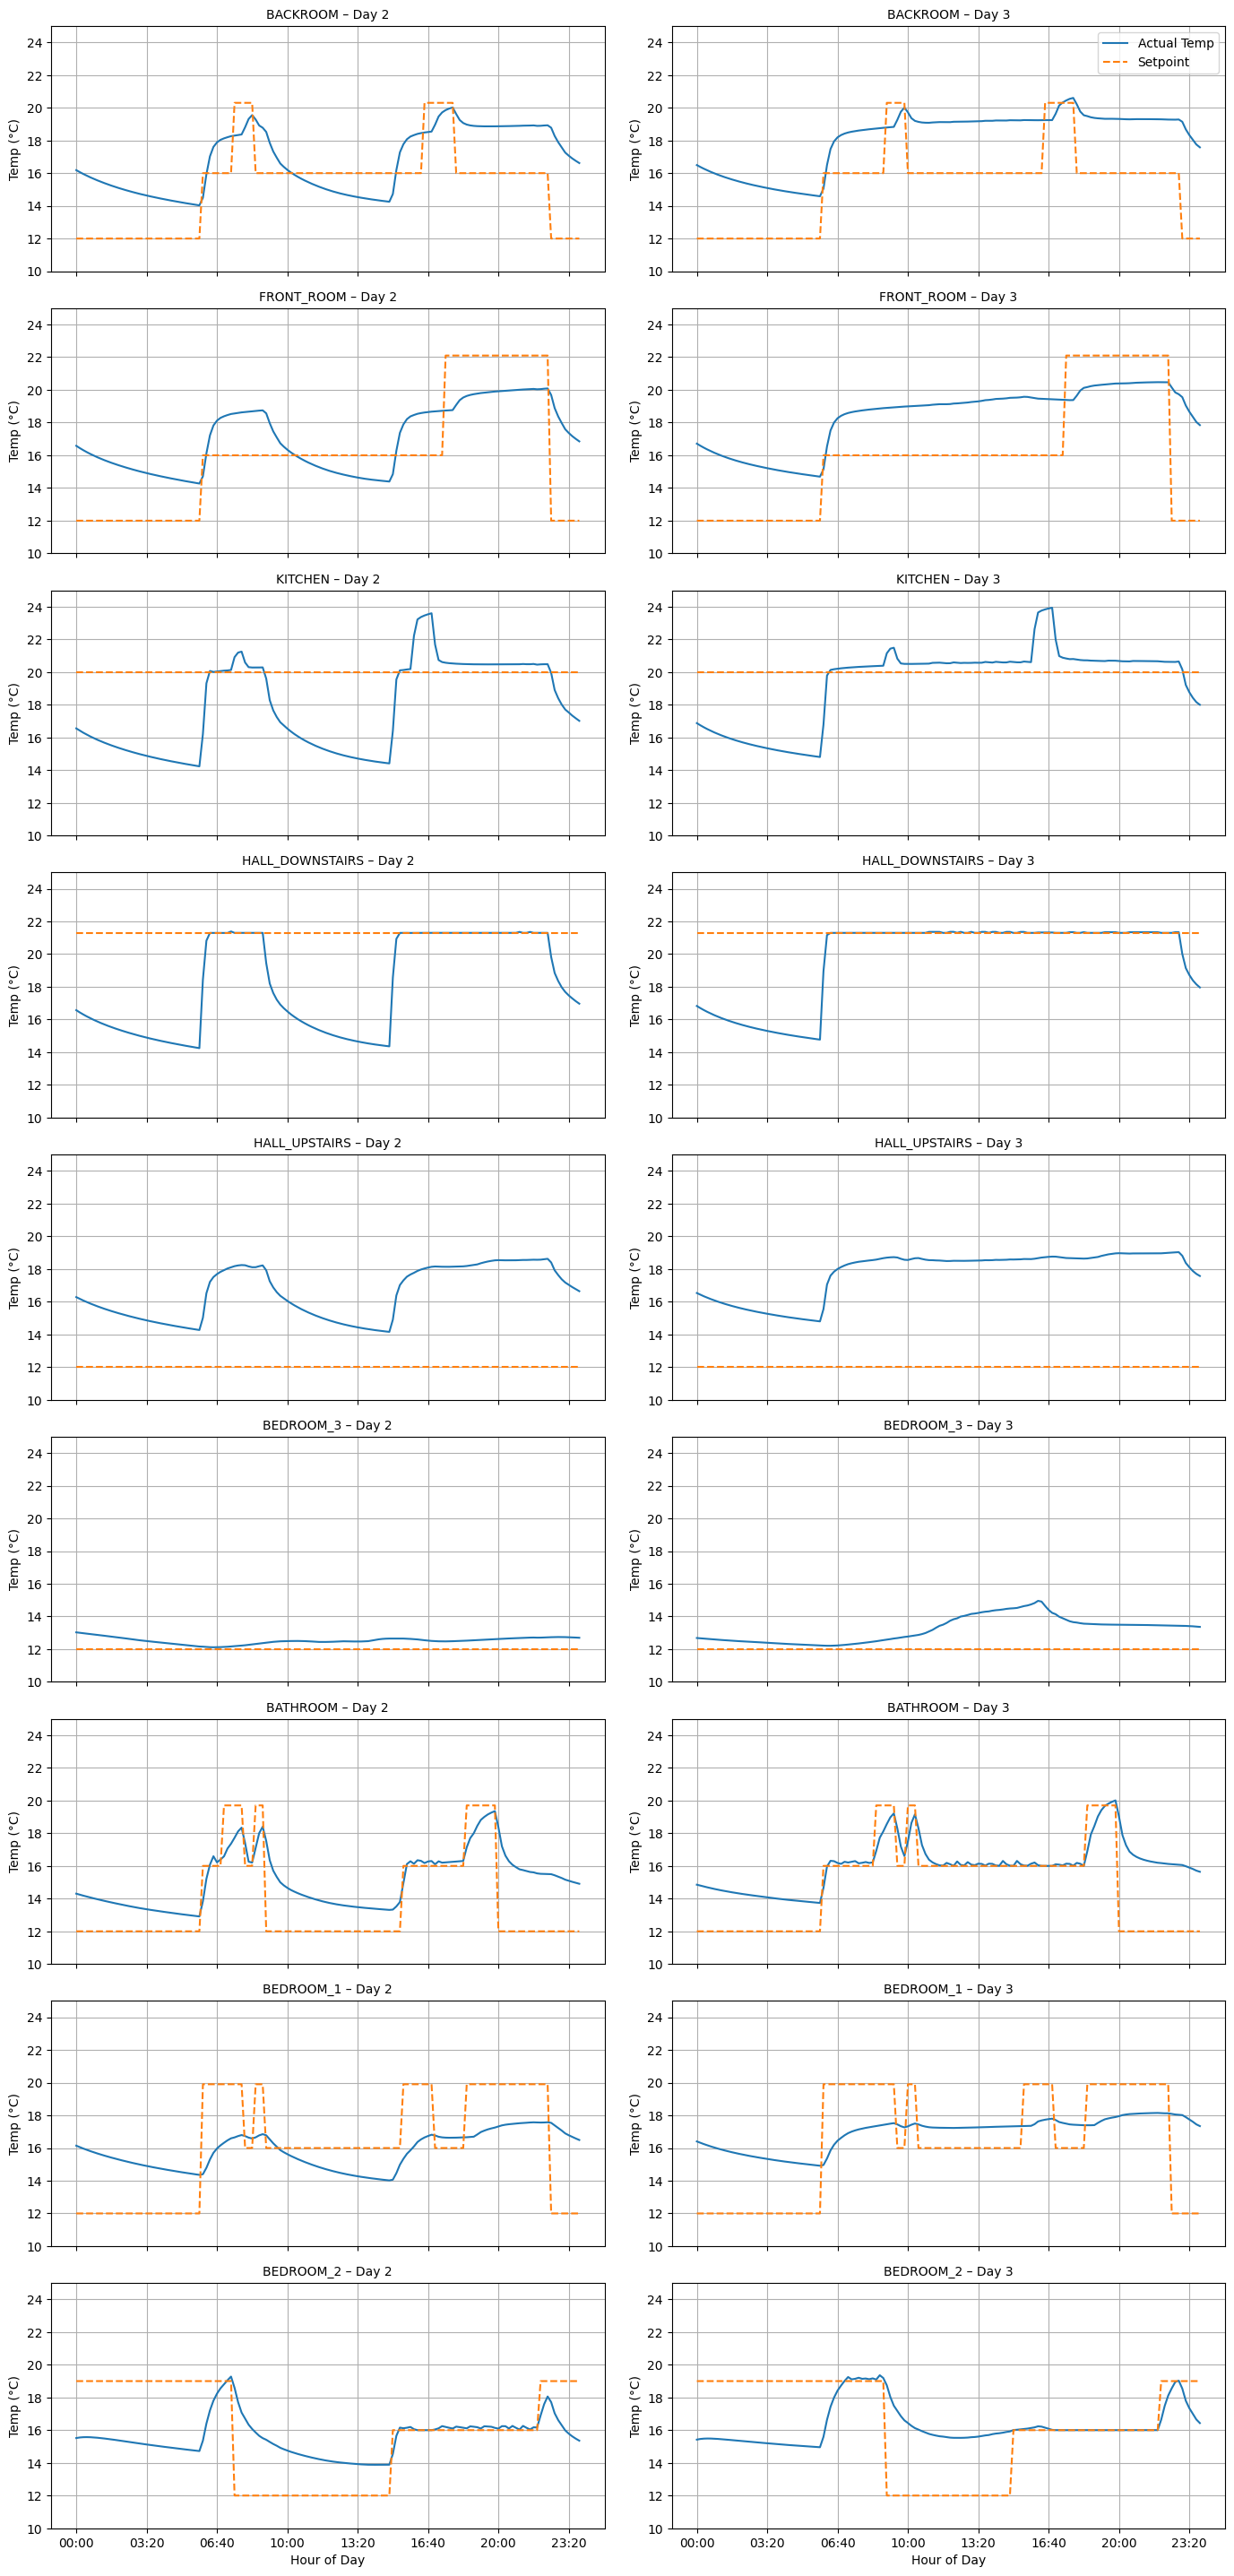

In [33]:
# eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso")
eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso")

# 🔹 Example Usage - Process Different Variables
split_temp, daily_temp = process_eso_variable("Zone Air Temperature")
split_setpoint, daily_setpoint = process_eso_variable("Zone Thermostat Heating Setpoint Temperature")




# Define the rooms and days
rooms = [
    "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
    "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
]
days = ["Day 2", "Day 3"]
period_name = "16th Feb – 15th Mar"

# Set up subplot grid
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(14, 30), sharex=True, sharey=False)
# fig.suptitle(f"Temperature vs. Setpoint – {period_name}", fontsize=16, y=0.92)

# Loop through rooms and days
for i, room in enumerate(rooms):
    for j, day in enumerate(days):
        ax = axes[i, j]
        temp_series = daily_temp[period_name][day][room]
        setpoint_series = daily_setpoint[period_name][day][room]

        temp_series.plot(ax=ax, label="Actual Temp", linestyle="-")
        setpoint_series.plot(ax=ax, label="Setpoint", linestyle="--")

        ax.set_title(f"{room} – {day}", fontsize=10)
        ax.set_ylim(10, 25)
        ax.set_ylabel("Temp (°C)")
        # ax.set_xticks(range(0, 24, 4))
        # ax.set_xticklabels([f"{h}:00" for h in range(0, 24, 4)])
        ax.grid(True)

        if i == len(rooms) - 1:
            ax.set_xlabel("Hour of Day")

        if i == 0 and j == 1:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


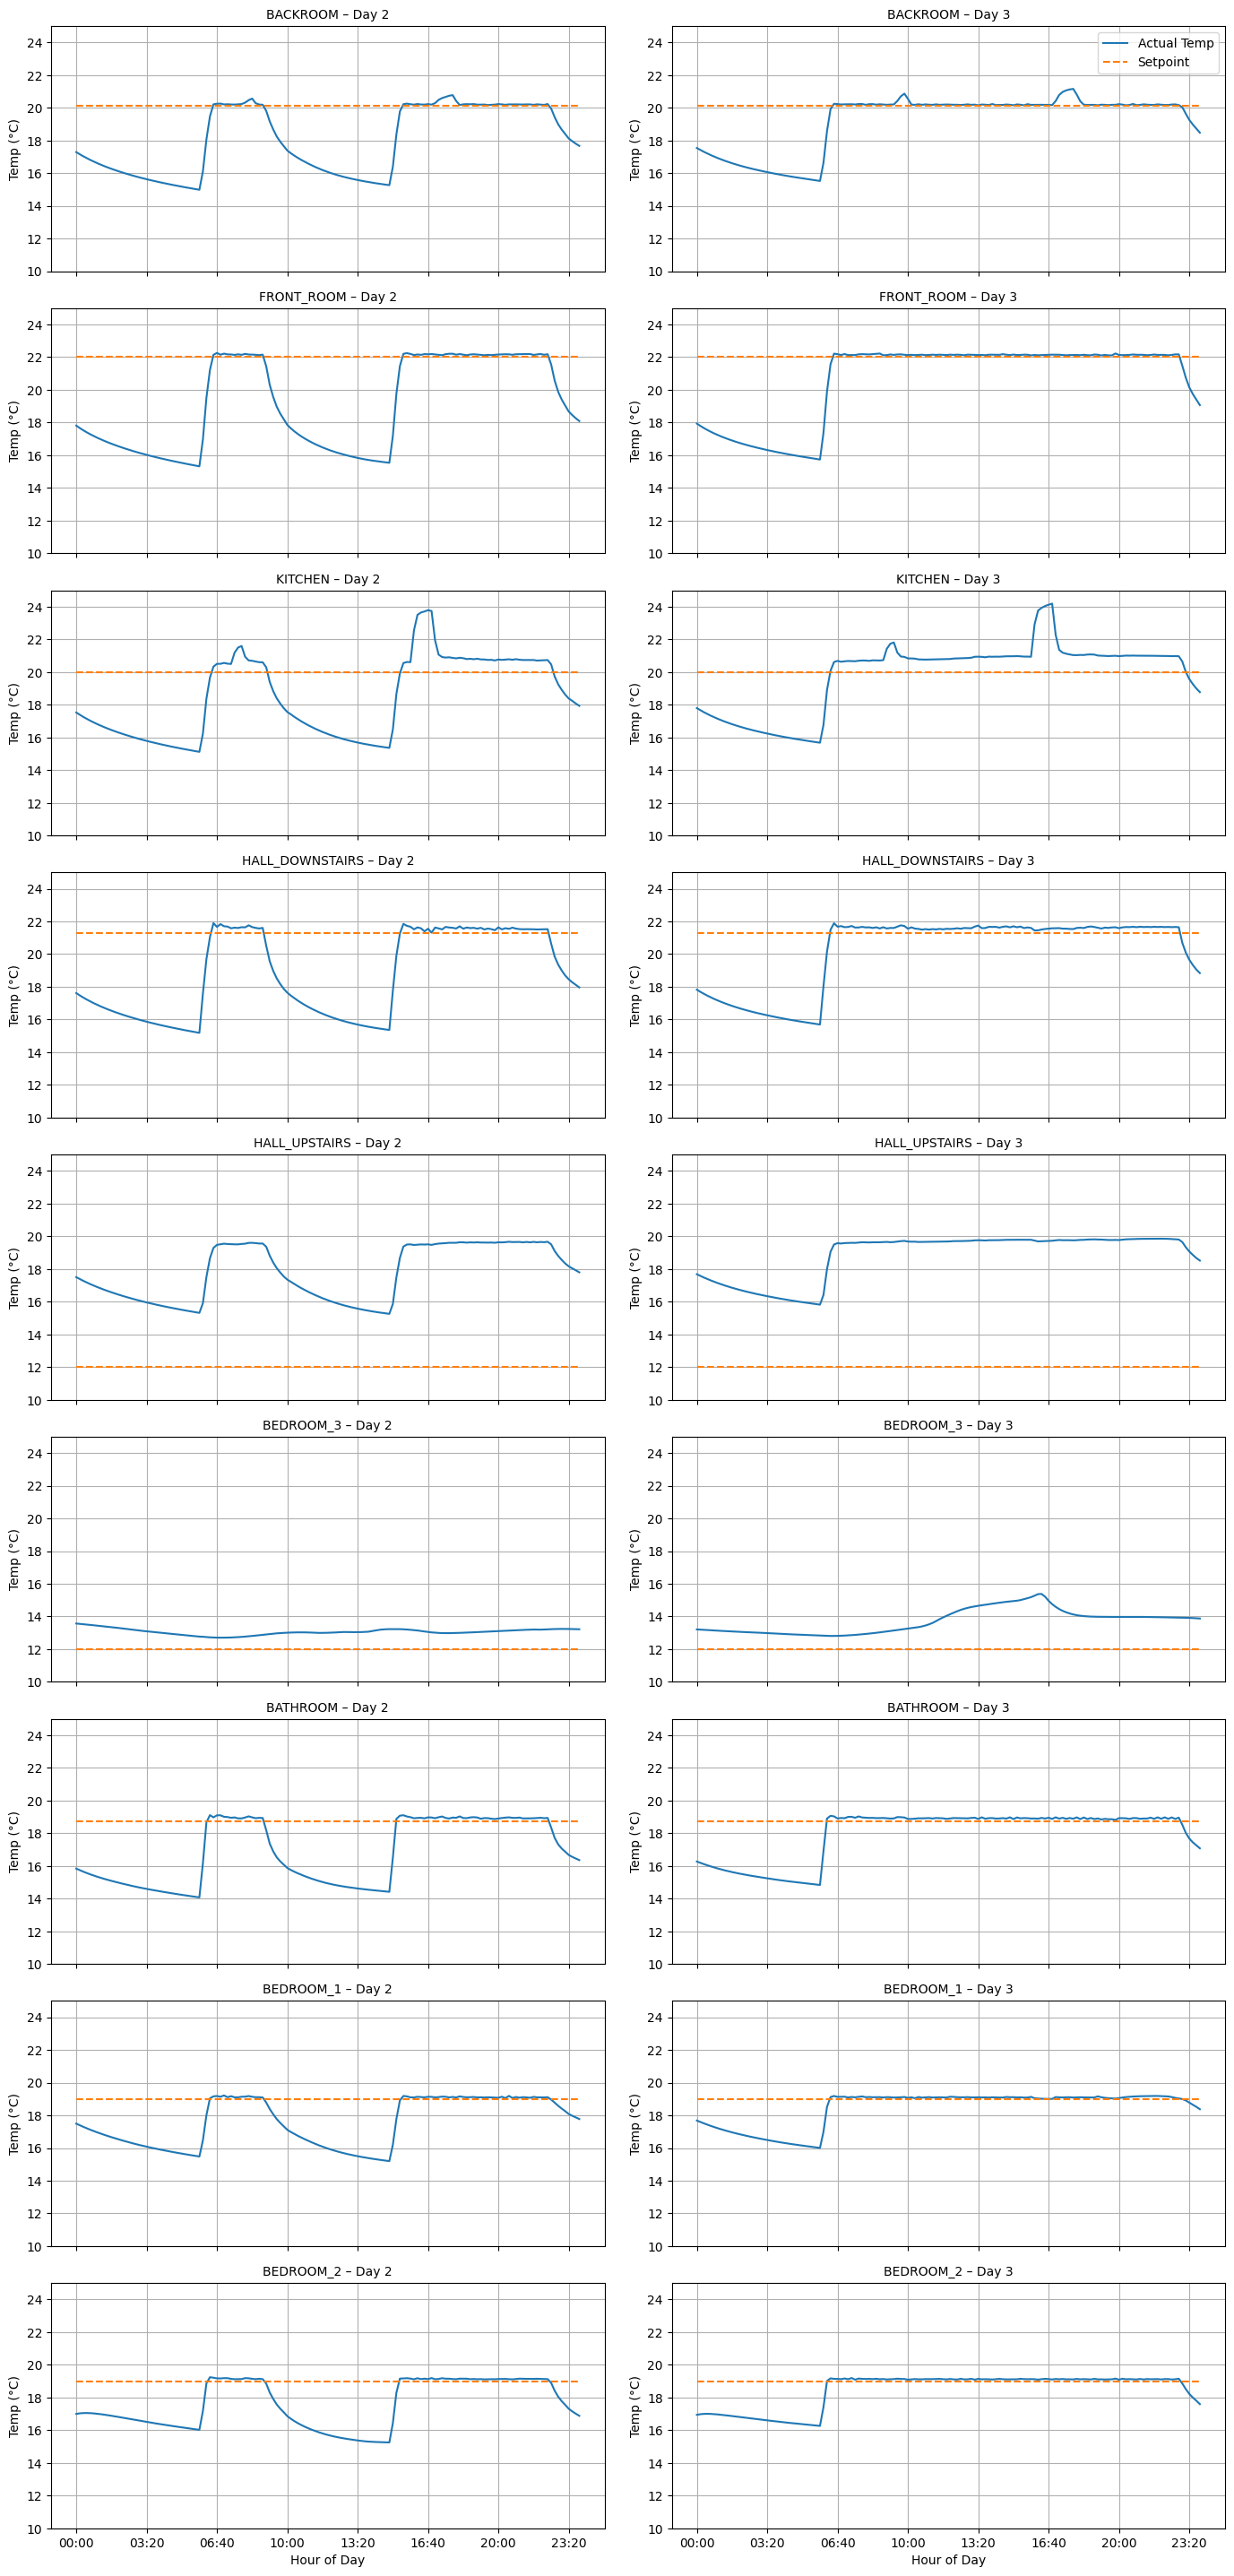

In [ ]:
# eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/conventional_control/eplusout.eso")
eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/zonal_control/eplusout.eso")

# 🔹 Example Usage - Process Different Variables
split_temp, daily_temp = process_eso_variable("Zone Air Temperature")
split_setpoint, daily_setpoint = process_eso_variable("Zone Thermostat Heating Setpoint Temperature")




# Define the rooms and days
rooms = [
    "BACKROOM", "FRONT_ROOM", "KITCHEN", "HALL_DOWNSTAIRS", "HALL_UPSTAIRS",
    "BEDROOM_3", "BATHROOM", "BEDROOM_1", "BEDROOM_2"
]
days = ["Day 2", "Day 3"]
period_name = "16th Feb – 15th Mar"

# Set up subplot grid
fig, axes = plt.subplots(nrows=9, ncols=2, figsize=(14, 30), sharex=True, sharey=False)
# fig.suptitle(f"Temperature vs. Setpoint – {period_name}", fontsize=16, y=0.92)

# Loop through rooms and days
for i, room in enumerate(rooms):
    for j, day in enumerate(days):
        ax = axes[i, j]
        temp_series = daily_temp[period_name][day][room]
        setpoint_series = daily_setpoint[period_name][day][room]

        temp_series.plot(ax=ax, label="Actual Temp", linestyle="-")
        setpoint_series.plot(ax=ax, label="Setpoint", linestyle="--")

        ax.set_title(f"{room} – {day}", fontsize=10)
        ax.set_ylim(10, 25)
        ax.set_ylabel("Temp (°C)")
        # ax.set_xticks(range(0, 24, 4))
        # ax.set_xticklabels([f"{h}:00" for h in range(0, 24, 4)])
        ax.grid(True)

        if i == len(rooms) - 1:
            ax.set_xlabel("Hour of Day")

        if i == 0 and j == 1:
            ax.legend(loc="upper right")

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()


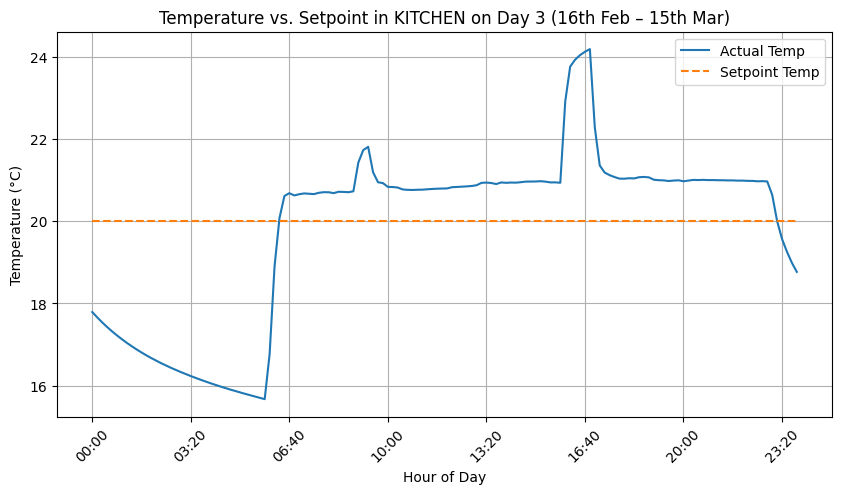

In [29]:


# 🔹 Example Plot: Compare Room Temperature vs. Setpoint
period_name = "16th Feb – 15th Mar"
day_name = "Day 3"
room = "KITCHEN"

plt.figure(figsize=(10, 5))
daily_temp[period_name][day_name][room].plot(label="Actual Temp", linestyle="-")
daily_setpoint[period_name][day_name][room].plot(label="Setpoint Temp", linestyle="--")
plt.xlabel("Hour of Day")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.title(f"Temperature vs. Setpoint in {room} on {day_name} ({period_name})")
plt.legend()
plt.grid()
plt.show()



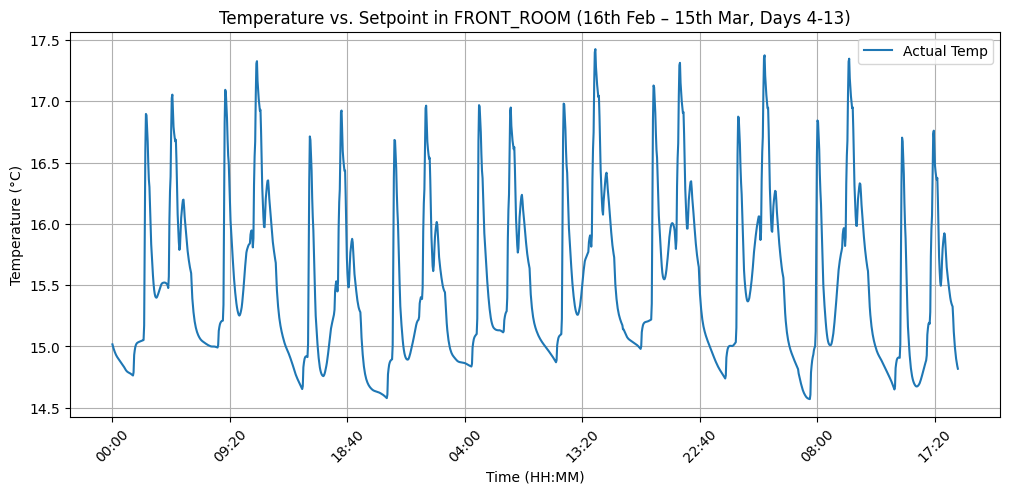

In [14]:
plot_eso_data(daily_temp, daily_setpoint, "16th Feb – 15th Mar", "FRONT_ROOM",
              "consecutive_days", start_day=4, num_days=10)


In [21]:
daily_temp[period_name][day_name][room].loc['02:40']


15.07370037614546

In [ ]:

split_outdoor, daily_outdoor = process_eso_variable("Site Outdoor Air Drybulb Temperature")
# 🔹 Example Plot: Outdoor Temperature Over Time
plt.figure(figsize=(10, 5))
split_outdoor[period_name]["Environment"].plot(label="Outdoor Temperature", linestyle="-", color="red")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.title(f"Outdoor Temperature Over Time ({period_name})")
plt.legend()
plt.grid()
plt.show()


In [1]:
import pandas as pd
from cubes.construct.buildingconfig import load_building_config
from cubes.construct.building import Building
from cubes.package.envconfig import EnvConfig


files_dir = "/workspaces/CUBES/exp/jack/paper/misc/input"
bc_file_path = "/workspaces/CUBES/exp/jack/beizaee_validation/case14.json"

materials = pd.read_pickle("/workspaces/CUBES/cubes/materials.pickle")
windows = pd.read_pickle("/workspaces/CUBES/cubes/windows.pickle")

BC = load_building_config(bc_file_path, files_dir=files_dir)
EC = EnvConfig(files_dir=files_dir)
building=Building(BC,materials,windows)

building.build()
idf = building.get_idf()



<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


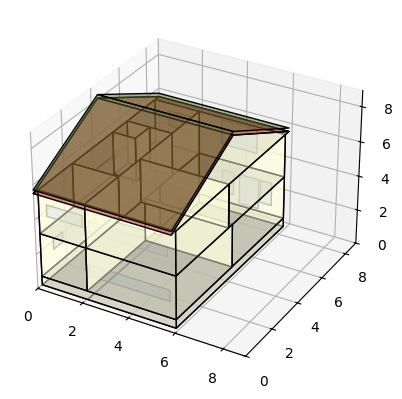

In [2]:
# idf.rotate(90)
idf.view_model()

In [3]:
idf.save("testing_build.idf")

In [4]:
from pathlib import Path
import os
from eppy.modeleditor import IDF

def test_idf():
    # Paths
    base_model_path = "/workspaces/CUBES/exp/jack/beizaee_validation/testing_build.idf"

    weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough_beizaee.epw"
    EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"
    iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
    IDF.setiddname(iddfile)

    # Load base model
    base_idf = IDF(base_model_path, weather_file_path)

    # ✅ Updated output directory structure: run_period/experiment
    output_dir = "/workspaces/CUBES/exp/jack/beizaee_validation/misc"
    Path(output_dir).mkdir(parents=True, exist_ok=True)

    idf_save_path = os.path.join(output_dir, "modified_test.idf")
    base_idf.save(filename=idf_save_path)
    base_idf.run(output_directory=output_dir)


In [5]:
test_idf()


/usr/local/EnergyPlus-9-5-0/energyplus --weather /workspaces/CUBES/cubes/data/weather/loughborough_beizaee.epw --output-directory /workspaces/CUBES/exp/jack/beizaee_validation/misc --idd /usr/local/EnergyPlus-9-5-0/Energy+.idd /workspaces/CUBES/exp/jack/beizaee_validation/in.idf

EnergyPlus Starting
EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2025.03.24 21:22
Initializing Response Factors
Calculating CTFs for "13"
Calculating CTFs for "19"
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "WALL-CONSTRUCTION"
Calculating CTFs for "ROOF-CONSTRUCTION"
Calculating CTFs for "GROUNDFLOOR-CONSTRUCTION"
Calculating CTFs for "GROUNDFLOOR-CONSTRUCTION"
Calculating CTFs for "FLOOR-CONSTRUCTION"
Calculating CTFs for "INTERNALWALL-CONSTRUCTION"
Calculating CTFs for "FURNITURE-CONSTRUCTION"
Calculating CTFs for "LAST FLOOR-CONSTRUCTION"
Calculating CTFs for "LAST FLOO

EnergyPlus Completed Successfully.


In [12]:
len(idf.idfobjects["BUILDINGSURFACE:DETAILED"])

121

In [ ]:
def add_zone_mixing_for_doors(idf, mixing_flow_rate=0.01):
    """Adds ZONECROSSMIXING objects for all doors that connect two zones."""

    added_mixing_pairs = set()  # Track added pairs to avoid duplicates

    # Iterate through all fenestration surfaces to find doors
    for door in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]:
        if door.Surface_Type.lower() == "door":
            # Get the parent surface
            parent_surface_name = door.Building_Surface_Name

            # Find the corresponding building surface object
            parent_surface = next(
                (surf for surf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
                 if surf.Name == parent_surface_name), None)

            if not parent_surface:
                continue  # Skip if no matching parent surface found

            # Get the zone the door belongs to
            zone_name = parent_surface.Zone_Name

            # Get the adjacent fenestration surface object
            adjacent_door = next(
                (other_door for other_door in idf.idfobjects["FENESTRATIONSURFACE:DETAILED"]
                 if other_door.Name == door.Outside_Boundary_Condition_Object), None)

            if not adjacent_door:
                continue  # Skip if no adjacent door found

            # Find the parent building surface of the adjacent door
            adjacent_surface = next(
                (surf for surf in idf.idfobjects["BUILDINGSURFACE:DETAILED"]
                 if surf.Name == adjacent_door.Building_Surface_Name), None)

            if not adjacent_surface:
                continue  # Skip if no adjacent building surface found

            adjacent_zone_name = adjacent_surface.Zone_Name

            # Ensure we have two different zones (not an external door)
            if zone_name and adjacent_zone_name and zone_name != adjacent_zone_name:
                zone_pair = tuple(sorted([zone_name, adjacent_zone_name]))  # Sort to maintain consistency

                if zone_pair in added_mixing_pairs:
                    continue  # Skip if this zone pair is already processed

                print(f"Adding zone mixing between {zone_name} and {adjacent_zone_name}")

                # Create bidirectional mixing (only once per unique zone pair)
                idf.newidfobject(
                    "ZONECROSSMIXING",
                    Name=f"{zone_name}_to_{adjacent_zone_name}_Mixing",
                    Zone_Name=zone_name,
                    Design_Flow_Rate=mixing_flow_rate,  # Set a constant value for now
                    Schedule_Name="AlwaysOnSchedule",
                    Source_Zone_Name=adjacent_zone_name,
                    Delta_Temperature=0.0
                )

                idf.newidfobject(
                    "ZONECROSSMIXING",
                    Name=f"{adjacent_zone_name}_to_{zone_name}_Mixing",
                    Zone_Name=adjacent_zone_name,
                    Design_Flow_Rate=mixing_flow_rate,  # Set a constant value for now
                    Schedule_Name="AlwaysOnSchedule",
                    Source_Zone_Name=zone_name,
                    Delta_Temperature=0.0
                )

                added_mixing_pairs.add(zone_pair)  # Mark this pair as added

    return idf


In [8]:
idf_file='/workspaces/CUBES/exp/jack/beizaee_validation/building_model_reformatted.idf'
weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough.epw"
idf = IDF(idf_file, weather_file_path)

len(idf.idfobjects["BUILDINGSURFACE:DETAILED"])

121

In [9]:
idf = add_zone_mixing_for_doors(idf, 0.1)

Adding zone mixing between kitchen and hall_downstairs
Adding zone mixing between backroom and hall_downstairs
Adding zone mixing between hall_downstairs and hall_upstairs
Adding zone mixing between hall_downstairs and front_room
Adding zone mixing between bathroom and hall_upstairs
Adding zone mixing between bedroom_1 and hall_upstairs
Adding zone mixing between hall_upstairs and wash_closet
Adding zone mixing between hall_upstairs and bedroom_3
Adding zone mixing between hall_upstairs and bedroom_2


In [10]:
idf.save("mixing.idf")

In [3]:
# print("Objects in IDF:")
# for obj_type in idf.idfobjects.keys():
#     if idf.idfobjects[obj_type]:  # ✅ Only print if the object type has instances
#         print(f"- {obj_type}")



/usr/local/EnergyPlus-9-5-0/energyplus --weather /workspaces/CUBES/cubes/data/weather/loughborough.epw --output-directory /workspaces/CUBES/exp/jack/beizaee_validation/input_case_1/output --idd /usr/local/EnergyPlus-9-5-0/Energy+.idd /workspaces/CUBES/exp/jack/beizaee_validation/in.idf

EnergyPlus Starting
EnergyPlus, Version 9.5.0-de239b2e5f, YMD=2025.03.12 08:22


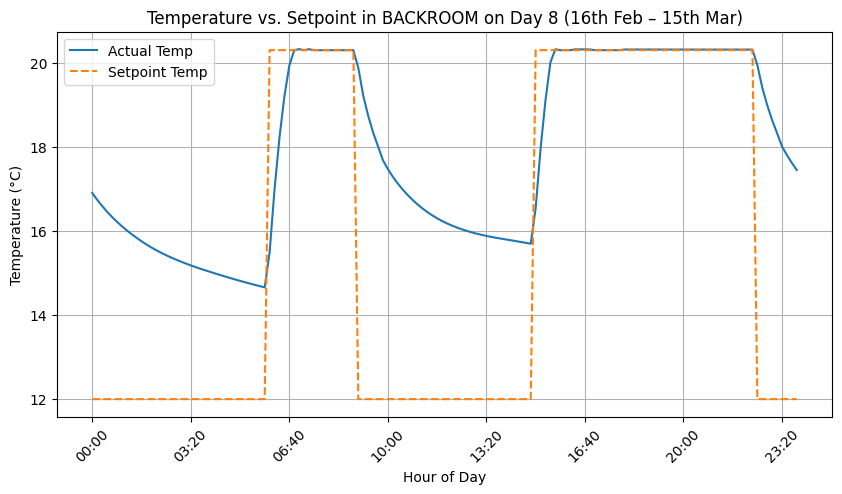

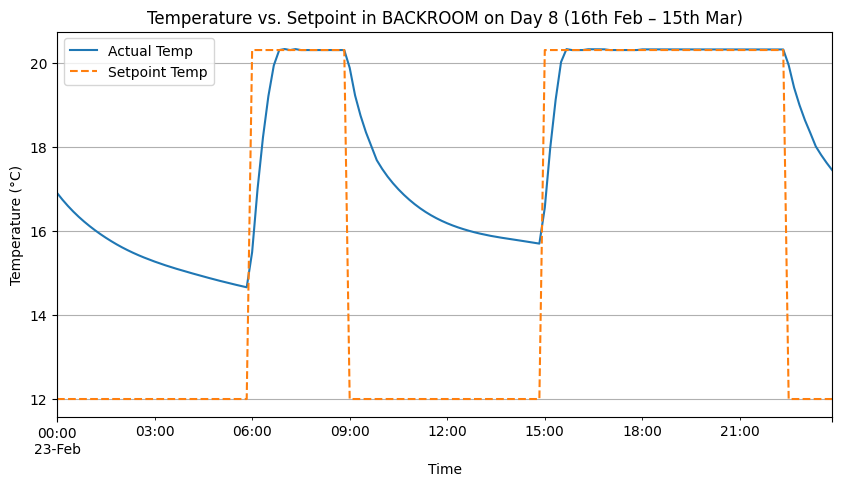

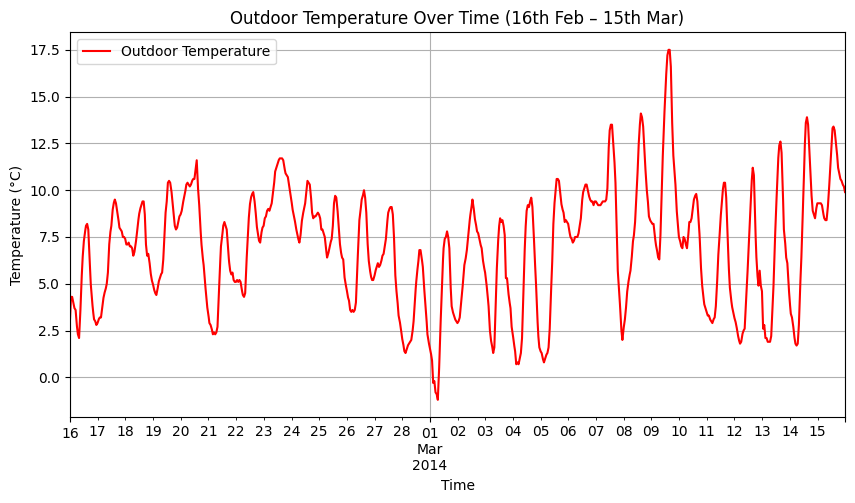

In [10]:
split_outdoor

{'16th Feb – 15th Mar':                      Environment
 2014-02-16 00:00:00     3.133333
 2014-02-16 00:10:00     3.366667
 2014-02-16 00:20:00     3.600000
 2014-02-16 00:30:00     3.833333
 2014-02-16 00:40:00     4.066667
 ...                          ...
 2014-03-15 23:10:00    10.100000
 2014-03-15 23:20:00    10.050000
 2014-03-15 23:30:00    10.000000
 2014-03-15 23:40:00     9.950000
 2014-03-15 23:50:00     9.900000
 
 [4032 rows x 1 columns],
 '18th Mar – 8th Apr':                      Environment
 2014-03-18 00:00:00     7.666667
 2014-03-18 00:10:00     7.633333
 2014-03-18 00:20:00     7.600000
 2014-03-18 00:30:00     7.566667
 2014-03-18 00:40:00     7.533333
 ...                          ...
 2014-04-08 23:10:00     5.900000
 2014-04-08 23:20:00     5.750000
 2014-04-08 23:30:00     5.600000
 2014-04-08 23:40:00     5.450000
 2014-04-08 23:50:00     5.300000
 
 [3168 rows x 1 columns],
 '16th Apr – 21st Apr': Empty DataFrame
 Columns: [Environment]
 Index: []}

In [15]:
df = eso.to_frame('BACKROOM-THERMOSTAT DUAL SP CONTROL-HEATING-EXT')
df

""


In [13]:
import esoreader

eso = esoreader.read_from_path("/workspaces/CUBES/exp/jack/beizaee_validation/input_case_1/output/eplusout.eso")

available_variables = eso.dd.variables
for var_id, var_info in available_variables.items():
    print(var_info)


['TimeStep', 'Environment', 'Site Outdoor Air Drybulb Temperature', 'C']
['TimeStep', 'Environment', 'Site Outdoor Air Relative Humidity', '%']
['TimeStep', 'Environment', 'Site Wind Speed', 'm/s']
['TimeStep', 'Environment', 'Site Diffuse Solar Radiation Rate per Area', 'W/m2']
['TimeStep', 'Environment', 'Site Direct Solar Radiation Rate per Area', 'W/m2']
['TimeStep', 'Environment', 'Site Rain Status', '']
['TimeStep', 'BACKROOM', 'Zone People Occupant Count', '']
['TimeStep', 'BATHROOM', 'Zone People Occupant Count', '']
['TimeStep', 'BEDROOM_1', 'Zone People Occupant Count', '']
['TimeStep', 'BEDROOM_2', 'Zone People Occupant Count', '']
['TimeStep', 'BEDROOM_3', 'Zone People Occupant Count', '']
['TimeStep', 'FRONT_ROOM', 'Zone People Occupant Count', '']
['TimeStep', 'HALL_DOWNSTAIRS', 'Zone People Occupant Count', '']
['TimeStep', 'HALL_UPSTAIRS', 'Zone People Occupant Count', '']
['TimeStep', 'KITCHEN', 'Zone People Occupant Count', '']
['TimeStep', 'BACKROOM', 'Zone Operative

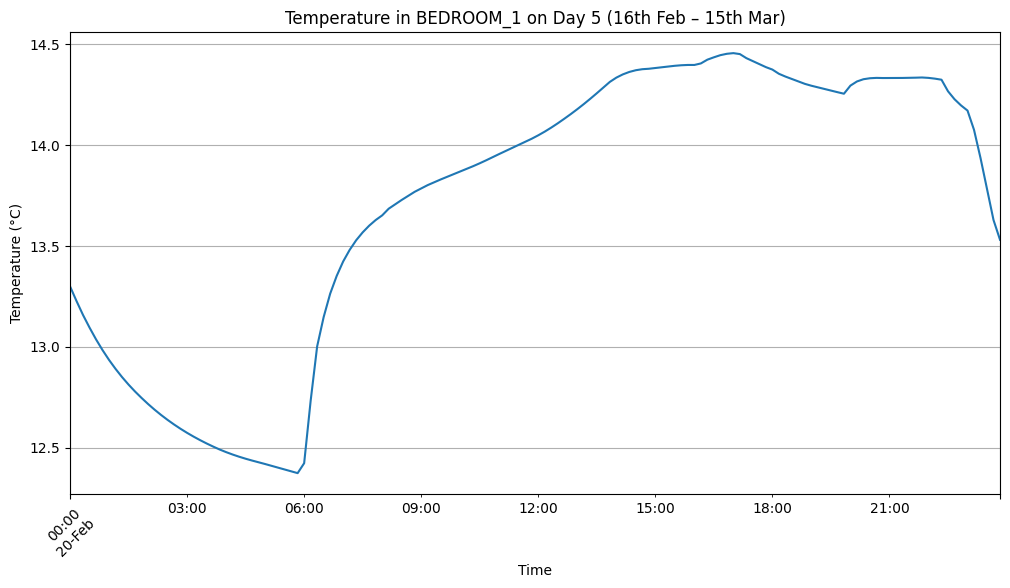

In [4]:
# Example: Plot a specific day's temperature for a specific room
period_name = "16th Feb – 15th Mar"
day_name = "Day 5"  # Change this to view other days
room = "BEDROOM_1"  # Change this to view other rooms

plt.figure(figsize=(12, 6))
daily_dfs[period_name][day_name][room].plot(title=f"Temperature in {room} on {day_name} ({period_name})")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.grid()
plt.show()


In [27]:
df

,BACKROOM,BATHROOM,BEDROOM_1,BEDROOM_2,BEDROOM_3,FRONT_ROOM,HALL_DOWNSTAIRS,HALL_UPSTAIRS,KITCHEN
0,11.077267,12.515459,12.370254,13.947651,12.726778,11.472862,11.622795,12.729125,11.421141
1,11.023598,12.410532,12.267625,13.796413,12.619539,11.408526,11.553603,12.628778,11.364530
2,10.968246,12.317980,12.171553,13.663548,12.523965,11.343074,11.487050,12.521682,11.304597
3,10.913151,12.221974,12.077607,13.540028,12.425962,11.278657,11.418156,12.425664,11.245940
4,10.857900,12.134127,11.988051,13.426615,12.336297,11.215005,11.352229,12.329554,11.186501
...,...,...,...,...,...,...,...,...,...
8059,15.665580,16.684582,16.522591,17.786562,16.800286,15.891432,16.020378,16.815001,15.943963
8060,15.634104,16.572332,16.454274,17.426739,16.684473,15.845010,15.962563,16.672466,15.901615
8061,15.593652,16.464195,16.363645,17.151969,16.568567,15.791972,15.909684,16.570616,15.854218
8062,15.563345,16.403535,16.301116,17.017104,16.504155,15.754508,15.868748,16.483186,15.820852


<Axes: >

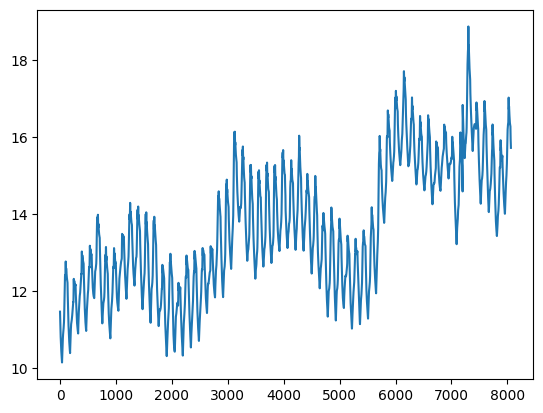

In [26]:
df['FRONT_ROOM'].plot()

In [16]:
idf_file='/workspaces/CUBES/exp/jack/beizaee_validation/building_model.idf'

idf = IDF(idf_file, weather_file_path)

In [17]:


# Loop through all ThermostatSetpoint:DualSetpoint objects
for thermostat in idf.idfobjects["THERMOSTATSETPOINT:DUALSETPOINT"]:
    heating_schedule_name = thermostat.Heating_Setpoint_Temperature_Schedule_Name  # Extract heating schedule name

    # Create Schedule:Compact for heating setpoints
    idf.newidfobject(
        "Schedule:Compact".upper(),
        Name=heating_schedule_name,
        Schedule_Type_Limits_Name="Temperature",
        Field_1="Through: 12/31",
        Field_2="For: AllDays",
        Field_3="Until: 07:00, 16.0",  # Night setback temperature
        Field_4="Until: 23:00, 20.0",  # Comfort temperature
        Field_5="Until: 24:00, 16.0",  # Back to setback
    )

    # Debug print
    print(f"Added Schedule:Compact for {heating_schedule_name}")

# Loop through all ZoneVentilation:DesignFlowRate objects
for ventilation in idf.idfobjects["ZONEVENTILATION:DESIGNFLOWRATE"]:
    ventilation_schedule_name = ventilation.Schedule_Name  # Extract schedule name

    # Create Schedule:Compact for ventilation (set to 0 at all times)
    idf.newidfobject(
        "Schedule:Compact".upper(),
        Name=ventilation_schedule_name,
        Schedule_Type_Limits_Name="Fraction",
        Field_1="Through: 12/31",
        Field_2="For: AllDays",
        Field_3="Until: 24:00, 0.0",  # No ventilation at all times
    )

    # Debug print
    print(f"Added Schedule:Compact with 0 ventilation for {ventilation_schedule_name}")

idf.save("building_model_reformatted.idf")

Added Schedule:Compact for backroom-thermostat dual sp control-heating-ext
Added Schedule:Compact for bathroom-thermostat dual sp control-heating-ext
Added Schedule:Compact for bedroom_1-thermostat dual sp control-heating-ext
Added Schedule:Compact for bedroom_2-thermostat dual sp control-heating-ext
Added Schedule:Compact for bedroom_3-thermostat dual sp control-heating-ext
Added Schedule:Compact for front_room-thermostat dual sp control-heating-ext
Added Schedule:Compact for hall_downstairs-thermostat dual sp control-heating-ext
Added Schedule:Compact for hall_upstairs-thermostat dual sp control-heating-ext
Added Schedule:Compact for kitchen-thermostat dual sp control-heating-ext
Added Schedule:Compact with 0 ventilation for backroom-ventilation-ext
Added Schedule:Compact with 0 ventilation for bathroom-ventilation-ext
Added Schedule:Compact with 0 ventilation for bedroom_1-ventilation-ext
Added Schedule:Compact with 0 ventilation for bedroom_2-ventilation-ext
Added Schedule:Compact 

In [ ]:
import os
from pathlib import Path
from eppy import modeleditor
from eppy.modeleditor import IDF

# Define EnergyPlus installation path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update if needed

# Set the IDD file path
iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
IDF.setiddname(iddfile)  # Load the IDD file


def remove_unwanted_objects(idf, object_list):
    """Removes specified EnergyPlus objects from an IDF file."""
    for obj_type in object_list:
        obj_type_upper = obj_type.upper()
        if obj_type_upper in idf.idfobjects:
            print(f"Removing: {obj_type_upper}")
            objects_to_remove = list(idf.idfobjects[obj_type_upper])  # Create a copy of the list
            for obj in objects_to_remove:
                idf.removeidfobject(obj)  # Remove from IDF

# List of objects to remove
remove_objs = [
    "Schedule:Compact",
    "SizingPeriod:DesignDay",
    "RunPeriod",
    "RunPeriodControl:DaylightSavingTime",
    "Site:GroundReflectance:SnowModifier",
    "Site:Precipitation",
    "ScheduleTypeLimits",
    "Schedule:Day:Hourly",
    "Schedule:Week:Daily",
    "Schedule:Week:Weekly",
    "Schedule:Compact",
    "ZONEHVAC:IDEALLOADSAIRSYSTEM",
    "People",
    "Lights",
    "OtherEquipment",
    "Sizing:Parameters",
    "Sizing:Zone",
    "ZoneControl:Thermostat",
    "ZoneHVAC:EquipmentList",
    "ZoneHVAC:EquipmentConnections",
    "NodeList",
    "OutputControl:Table:Style",
    "OutputControl:ReportingTolerances",
    "Output:Variable",
    "Output:Meter",
    "Output:EnvironmentalImpactFactors",
    "EnvironmentalImpactFactors",
    "Output:Diagnostics",
    'Output:Table:SummaryReports',
    'WaterUse:Equipment',
    'ThermostatSetpoint:DualSetpoint',
    'ZoneVentilation:DesignFlowRate',
    'ZoneInfiltration:DesignFlowRate',
    'RoofIrrigation',
]

idf_path = "/workspaces/CUBES/exp/jack/beizaee_validation/finished.idf"  # Update this with the correct file path
idf = IDF(idf_path)

# # Remove unwanted objects
# remove_unwanted_objects(idf, remove_objs)

# # Save the cleaned IDF file
# idf.save("updated_geometry_cleaned.idf")

# print("IDF cleaning complete. Saved as 'updated_geometry_cleaned.idf'.")


In [ ]:
# Find the surface with the given name
target_surface_name = "hall_downstairs_Ceiling_1_0_6"

# Loop through all surfaces to find the matching one
for surface in idf.idfobjects["BUILDINGSURFACE:DETAILED"]:
    if surface.Name == target_surface_name:
        print(f"Found Surface: {surface.Name}")
        print(f"Area is: {surface.area}")

        break
else:
    print(f"Surface '{target_surface_name}' not found in IDF.")


Found Surface: hall_downstairs_Ceiling_1_0_6
Area is: 1.9738563469761343


In [4]:
surface.area


np.float64(11.478543228676694)

In [20]:
import os
from pathlib import Path
from eppy import modeleditor
from eppy.modeleditor import IDF

# Define EnergyPlus installation path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update if needed

# Set the IDD file path
iddfile = os.path.join(EPLUS_PATH, "Energy+.idd")
IDF.setiddname(iddfile)  # Load the IDD file

# Define the path to the IDF file exported from DesignBuilder
idf_file = "/workspaces/CUBES/exp/jack/paper/converted_zones.idf"  # Update with actual file

# Define the weather file path
weather_file_path = "/workspaces/CUBES/cubes/data/weather/loughborough.epw"  # Update this path

# ✅ Initialize IDF with both the IDF file and Weather file
idf = IDF(idf_file, weather_file_path)

# Print IDF summary
print("IDF Version:", idf.idfobjects["VERSION"])
print("Number of objects:", len(idf.idfobjects))

# Define the test function to run the simulation
def test_idf(idf):
    # Define paths for saving and output
    cwd_path = os.getcwd()
    env_data_path = os.path.join(cwd_path, "input_case_1")
    Path(env_data_path).mkdir(parents=True, exist_ok=True)

    # Save the modified IDF
    idf.save(filename=os.path.join(env_data_path, "test1.idf"))

    # Define output directory
    output_directory = os.path.join(env_data_path, "output/")
    Path(output_directory).mkdir(parents=True, exist_ok=True)

    # ✅ Run EnergyPlus simulation (No need to pass weather file separately now)
    idf.run(output_directory=output_directory)

# Run the test function
# test_idf(idf)


IDF Version: [
Version,
    9.4.0.002;                !- Version Identifier
]
Number of objects: 821


In [1]:
def remove_unwanted_objects(idf, object_list):
    """Removes specified EnergyPlus objects from an IDF file."""
    for obj_type in object_list:
        obj_type_upper = obj_type.upper()
        if obj_type_upper in idf.idfobjects:
            print(f"Removing: {obj_type_upper}")
            objects_to_remove = list(idf.idfobjects[obj_type_upper])  # Create a copy of the list
            for obj in objects_to_remove:
                idf.removeidfobject(obj)  # Remove from IDF

# List of objects to remove
remove_objs = [
    "Schedule:Compact",
    "SizingPeriod:DesignDay",
    "RunPeriod",
    "RunPeriodControl:DaylightSavingTime",
    "Site:GroundReflectance:SnowModifier",
    "Site:Precipitation",
    "ScheduleTypeLimits",
    "Schedule:Day:Hourly",
    "Schedule:Week:Daily",
    "Schedule:Week:Weekly",
    "Schedule:Compact",
    "ZONEHVAC:IDEALLOADSAIRSYSTEM",
    "People",
    "Lights",
    "OtherEquipment",
    "Sizing:Parameters",
    "Sizing:Zone",
    "ZoneControl:Thermostat",
    "ZoneHVAC:EquipmentList",
    "ZoneHVAC:EquipmentConnections",
    "NodeList",
    "OutputControl:Table:Style",
    "OutputControl:ReportingTolerances",
    "Output:Variable",
    "Output:Meter",
    "Output:EnvironmentalImpactFactors",
    "EnvironmentalImpactFactors",
    "Output:Diagnostics",
    'Output:Table:SummaryReports',
    'WaterUse:Equipment'
]

# Load your IDF file
from eppy import modeleditor
from eppy.modeleditor import IDF

idf_path = "/workspaces/CUBES/exp/jack/paper/converted_zones.idf"  # Update this with the correct file path
idf = IDF(idf_path)

# Remove unwanted objects
remove_unwanted_objects(idf, remove_objs)

# Save the cleaned IDF file
idf.save("updated_geometry_cleaned.idf")

print("IDF cleaning complete. Saved as 'updated_geometry_cleaned.idf'.")


IDDNotSetError: IDD file needed to read the idf file. Set it using IDF.setiddname(iddfile)

In [5]:
from eppy import modeleditor
from eppy.modeleditor import IDF

# Set EnergyPlus IDD file path
EPLUS_PATH = "/usr/local/EnergyPlus-9-5-0/"  # Update based on your system
iddfile = EPLUS_PATH + "Energy+.idd"
IDF.setiddname(iddfile)

# Load your IDF file from DesignBuilder
idf_file = "/workspaces/CUBES/exp/idontknow.idf"  # Update with actual file path
idf = IDF(idf_file)

# ✅ Check if AirflowNetwork is enabled
afn_objects = idf.idfobjects.get("AIRFLOWNETWORK:MULTIZONE", [])
if afn_objects:
    print("❌ Airflow Network is ENABLED (Should NOT be used)")
else:
    print("✅ Airflow Network is NOT used (Correct for SNV)")

✅ Airflow Network is NOT used (Correct for SNV)


In [15]:


# ✅ Check Scheduled Natural Ventilation
print("\n🔹 Checking 'ZoneVentilation:DesignFlowRate' (Scheduled Natural Ventilation)...")
for vent in idf.idfobjects.get("ZONEVENTILATION:DESIGNFLOWRATE", []):
    print(f"Zone: {vent.Name}, Flow Rate: {vent.Design_Flow_Rate}, Schedule: {vent.Schedule_Name}")

# ✅ Check Infiltration Rates
print("\n🔹 Checking 'ZoneInfiltration:DesignFlowRate' (Infiltration Settings)...")
for infil in idf.idfobjects.get("ZONEINFILTRATION:DESIGNFLOWRATE", []):
    print(f"Zone: {infil.Name}, Flow Rate: {infil.Design_Flow_Rate}, Schedule: {infil.Schedule_Name}")

# ✅ Check Inter-Zone Mixing
print("\n🔹 Checking 'ZoneMixing' (Inter-Zone Airflow)...")
for mix in idf.idfobjects.get("ZONEMIXING", []):
    print(f"From Zone: {mix.Name}, To Zone: {mix.Zone_or_ZoneList_Name}, Flow Rate: {mix.Design_Flow_Rate}, Schedule: {mix.Schedule_Name}")

# ✅ Check Discharge Coefficients
print("\n🔹 Checking Discharge Coefficients (For Openings)...")
for window in idf.idfobjects.get("FENESTRATIONSURFACE:DETAILED", []):
    print(f"Window: {window.Name}, Type: {window.Surface_Type},")# Discharge Coeff: {window.Coordinates}")

# ✅ Check Subfloor Ventilation ACH
print("\n🔹 Checking Subfloor Ventilation Rate...")
for subfloor in idf.idfobjects.get("ZONEINFILTRATION:DESIGNFLOWRATE", []):
    print(subfloor)
    if "subfloor" in subfloor.Name.lower():
        print(f"Subfloor Zone: {subfloor.Name}, ACH: {subfloor.Design_Flow_Rate}")

print("\n✅ IDF Analysis Complete! Review the extracted values above.")



🔹 Checking 'ZoneVentilation:DesignFlowRate' (Scheduled Natural Ventilation)...
Zone: 1054 Nat Vent, Flow Rate: 0.010889, Schedule: 6072
Zone: 1061 Nat Vent, Flow Rate: 0.04617, Schedule: 6072
Zone: 1072 Nat Vent, Flow Rate: 1.4e-05, Schedule: 6072
Zone: 1134 Nat Vent, Flow Rate: 0.042534, Schedule: 6072
Zone: 1151 Nat Vent, Flow Rate: 0.001998, Schedule: 6072
Zone: 1159 Nat Vent, Flow Rate: 0.017623, Schedule: 6072
Zone: 1168 Nat Vent, Flow Rate: 0.011949, Schedule: 6072

🔹 Checking 'ZoneInfiltration:DesignFlowRate' (Infiltration Settings)...
Zone: 430 Infiltration, Flow Rate: 0.003421, Schedule: 2
Zone: 437 Infiltration, Flow Rate: 0.009314, Schedule: 2
Zone: 448 Infiltration, Flow Rate: 2e-06, Schedule: 2
Zone: 506 Infiltration, Flow Rate: 0.008474, Schedule: 2
Zone: 523 Infiltration, Flow Rate: 0.005647, Schedule: 2
Zone: 1054 Infiltration, Flow Rate: 0.001524, Schedule: 2
Zone: 1061 Infiltration, Flow Rate: 0.006464, Schedule: 2
Zone: 1072 Infiltration, Flow Rate: 2e-06, Schedule:

[]

In [28]:
import pandas as pd

# Define the specific columns and patterns you want to load
cols_to_load = [
    'Environmental Impact NaturalGas Source Energy(Site)',
    'Environmental Impact Total CO2 Emissions Carbon Equivalent Mass(Site)',
    'timestep', 'year', 'month', 'day', 'hour'
]

# Load the data while including all columns with "Zone Air Temperature"
df_conventional = pd.read_csv(
    "beizaee_manual_control.csv",
    usecols=lambda col: col in cols_to_load or "Zone Air Temperature" in col
)

df_zonal = pd.read_csv(
    "beizaee_zonal_control.csv",
    usecols=lambda col: col in cols_to_load or "Zone Air Temperature" in col
)

# df_conventional = pd.read_csv(
#     "beizaee_90_infil5.csv",
#     usecols=lambda col: col in cols_to_load or "Zone Air Temperature" in col
# )



In [29]:
# Define the filtering function
def filter_data(df):
    condition1 = (df['year'] == 2014) & (df['month'] < 2)
    # condition2 = (df['year'] == 2014) & (df['month'] == 3) & (df['day'] <= 15)
    # condition3 = (df['year'] == 2014) & (df['month'] == 3) & (df['day'] >= 18)
    # condition4 = (df['year'] == 2014) & (df['month'] == 4) & (df['day'] <= 8)
    # condition5 = (df['year'] == 2014) & (df['month'] == 4) & (df['day'] >= 16) & (df['day'] <= 21)

    return df[condition1]

In [30]:
df_conventional_feb = filter_data(df_conventional)

<Axes: >

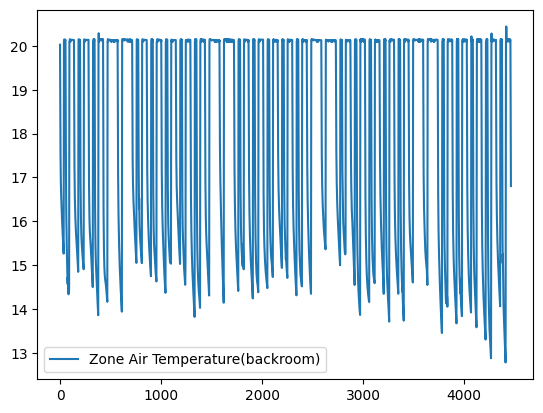

In [31]:
df_conventional_feb[["Zone Air Temperature(backroom)"]].plot()

In [32]:
energy_j = df_conventional["Environmental Impact NaturalGas Source Energy(Site)"].sum()
energy_kwh_conventional = energy_j / (3.6 * 10**6)
print(energy_kwh_conventional)


15113.961069234592


In [33]:
# Define the filtering function
def filter_data(df):
    condition1 = (df['year'] == 2014) & (df['month'] == 2) & (df['day'] >= 16)
    condition2 = (df['year'] == 2014) & (df['month'] == 3) & (df['day'] <= 15)
    # condition3 = (df['year'] == 2014) & (df['month'] == 3) & (df['day'] >= 18)
    # condition4 = (df['year'] == 2014) & (df['month'] == 4) & (df['day'] <= 8)
    # condition5 = (df['year'] == 2014) & (df['month'] == 4) & (df['day'] >= 16) & (df['day'] <= 21)

    return df[condition1 | condition2 ] # | condition3 | condition4 | condition5]


# Apply the filtering function to both DataFrames
filtered_df_conventional = filter_data(df_conventional)
filtered_df_zonal = filter_data(df_zonal)



In [34]:
# Get unique days in the filtered DataFrame
unique_days = filtered_df_conventional[['year', 'month', 'day']].drop_duplicates()

# Count the unique days
total_days = len(unique_days)
print(f"Total unique days: {total_days}")


Total unique days: 28


In [35]:

energy_j = filtered_df_conventional["Environmental Impact NaturalGas Source Energy(Site)"].sum()
energy_kwh_conventional = energy_j / (3.6 * 10**6)
print(energy_kwh_conventional)


1873.1024195666669


In [36]:

energy_j = filtered_df_zonal["Environmental Impact NaturalGas Source Energy(Site)"].sum()
energy_kwh_zonal = energy_j / (3.6 * 10**6)
print(energy_kwh_zonal)


1475.447161411667


In [37]:
energy_kwh_zonal/energy_kwh_conventional

np.float64(0.7877023413129777)

In [38]:
energy_kwh_conventional/total_days

np.float64(66.89651498452382)

In [39]:
energy_kwh_zonal/total_days

np.float64(52.69454147898811)

In [40]:
filtered_cols = [col for col in filtered_df_conventional.columns if "Zone Air Temperature" in col and not col.endswith(".1")]



In [41]:
temp_df = filtered_df_conventional[filtered_cols]
avg_temps = temp_df.mean(axis=1)
avg_temps.mean()

np.float64(17.587645333925817)

In [42]:
zonal_temp_df = filtered_df_zonal[filtered_cols]
avg_temps = zonal_temp_df.mean(axis=1)
avg_temps.mean()


np.float64(15.745969142719355)

In [45]:
filtered_df_conventional["Zone Air Temperature(backroom)"].mean()

np.float64(18.257261369791664)

In [50]:
filtered_df_conventional["Zone Air Temperature(backroom)"].iloc[30:50]

6654    14.448747
6655    14.414511
6656    14.378416
6657    14.341269
6658    14.303585
6659    14.265695
6660    14.227818
6661    16.435352
6662    19.358873
6663    20.099905
6664    20.099134
6665    20.156818
6666    20.153444
6667    20.151798
6668    20.150553
6669    20.149593
6670    20.148415
6671    20.147655
6672    20.147005
6673    20.146100
Name: Zone Air Temperature(backroom), dtype: float64

In [46]:
filtered_df_zonal["Zone Air Temperature(backroom)"].mean()

np.float64(16.038445827752977)

In [4]:
import numpy as np

# Example: Observation and Observation Space
obs = np.array(
    [
  2.0140000e+03, 1.0000000e+00, 1.0000000e+00, 0.0000000e+00, 7.3000002e+00,
  9.2000000e+01, 2.6199999e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 1.5200000e+01,
  0.0000000e+00, 0.0000000e+00, 1.9382532e+01, 2.0000925e+01, 2.0000925e+01,
  1.9434900e+01, 2.0000608e+01, 2.0000608e+01, 1.9424717e+01, 2.0000656e+01,
  2.0000656e+01, 1.9418400e+01, 2.0000784e+01, 2.0000784e+01, 1.9471926e+01,
  2.0001047e+01, 2.0001047e+01, 1.9516518e+01, 2.0000738e+01, 2.0000738e+01,
  1.9719770e+01, 2.0000801e+01, 2.0000801e+01, 1.9465467e+01, 2.0000969e+01,
  2.0000969e+01, 1.9539846e+01, 2.0000973e+01, 2.0000973e+01, 4.1979038e+01,
  4.1940060e+01, 4.2033306e+01, 4.1961708e+01, 4.1702629e+01, 4.1674862e+01,
  4.1684322e+01, 4.1675468e+01, 4.1665508e+01, 4.2452734e+02, 4.2210858e+02,
  4.2777289e+02, 4.2344989e+02, 4.2256744e+02, 4.2083499e+02, 4.2141974e+02,
  4.2090765e+02, 4.2030319e+02, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 2.0000000e+01, 2.0000000e+01, 2.0000000e+01, 2.0000000e+01,
  2.0000000e+01, 2.0000000e+01, 2.0000000e+01, 2.0000000e+01, 2.0000000e+01,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
  0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 7.8000002e+00, 3.2599998e+01,
  6.5100002e+00]
)

observation_space_low = np.array(
    [
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00, -1.5e+01,  0.0e+00,  0.0e+00, -1.0e+08,
 -1.0e+08,  0.0e+00,  0.0e+00,  0.0e+00, -1.0e+05, -1.0e+05, -1.0e+08,  0.0e+00,
 -1.0e+08,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,
  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,
  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,
  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  4.0e+02,  4.0e+02,  4.0e+02,
  4.0e+02,  4.0e+02,  4.0e+02,  4.0e+02,  4.0e+02,  4.0e+02,  0.0e+00,  0.0e+00,
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  1.0e+01,
  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,  1.0e+01,
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,
  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,  0.0e+00,
  0.0e+00,  0.0e+00, -1.0e+08, -1.0e+08, -1.5e+01],

)
observation_space_high = np.array(
    [
 3.0000000e+03, 1.2000000e+01, 3.1000000e+01, 2.4000000e+01, 4.0000000e+01,
 1.0000000e+02, 5.0000000e+01, 1.0000000e+08, 1.0000000e+08, 1.0000000e+00,
 3.9602339e-02, 1.2693067e+04, 1.0000000e+05, 1.0000000e+05, 1.0000000e+08,
 1.2693067e+04, 1.0000000e+08, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 1.0000000e+02,
 1.0000000e+02, 1.0000000e+02, 1.0000000e+02, 1.0000000e+02, 1.0000000e+02,
 1.0000000e+02, 1.0000000e+02, 1.0000000e+02, 1.0000000e+04, 1.0000000e+04,
 1.0000000e+04, 1.0000000e+04, 1.0000000e+04, 1.0000000e+04, 1.0000000e+04,
 1.0000000e+04, 1.0000000e+04, 4.0000000e+00, 4.0000000e+00, 4.0000000e+00,
 4.0000000e+00, 4.0000000e+00, 4.0000000e+00, 4.0000000e+00, 4.0000000e+00,
 4.0000000e+00, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01, 4.0000000e+01,
 1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01,
 1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+01, 1.0000000e+00,
 1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+00,
 1.0000000e+00, 1.0000000e+00, 1.0000000e+00, 1.0000000e+08, 1.0000000e+08,
 4.0000000e+01]
)

# Check which elements are outside the bounds
violations_low = obs < observation_space_low
violations_high = obs > observation_space_high

# Print the results
print("Indices below lower bounds:", np.where(violations_low)[0])
print("Values below lower bounds:", obs[violations_low])
print("Indices above upper bounds:", np.where(violations_high)[0])
print("Values above upper bounds:", obs[violations_high])


Indices below lower bounds: []
Values below lower bounds: []
Indices above upper bounds: []
Values above upper bounds: []


In [5]:
len(obs)

101

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


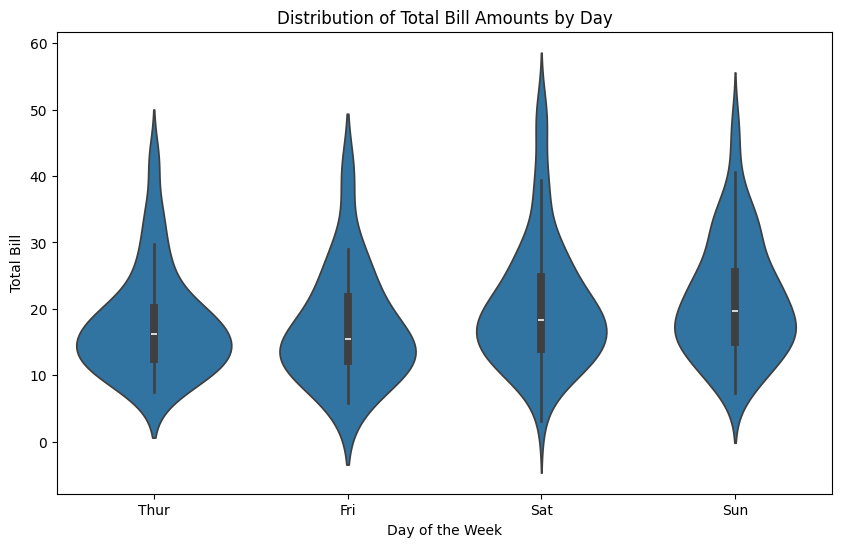

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the example dataset
tips = sns.load_dataset("tips")

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="day", y="total_bill", data=tips)

# Add labels and title
plt.xlabel("Day of the Week")
plt.ylabel("Total Bill")
plt.title("Distribution of Total Bill Amounts by Day")

# Show the plot
plt.show()


In [1]:
action = [1.0, 1.0, 1.0, 1.0, -1.0, -1.0, 1.0, 1.0, 1.0, 0.6923076923076923, -1.0, 0.6923076923076923, 0.6923076923076923, 0.23076923076923084, 0.23076923076923084, 0.6923076923076923, 0.6923076923076923, -1.0]

In [2]:
import Union
import numpy as np
from typing import List, Tuple, Any
def _setpoints_transform_gpt(
        self, action: Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]
    ) -> Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]:
        """This method transforms an action defined in gym
        (-1,1 in all continuous environment) action space
        to simulation real action space.

        Args:
            action (Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]):
            Action received in environment

        Returns:
            Union[int, float, np.integer, np.ndarray, List[Any], Tuple[Any]]:
            Action transformed in simulator action space.
        """
        action_ = []



        for i, value in enumerate(action):


            if self.action_space.low[i] <= value <= self.action_space.high[i]:
                a_max_min = self.action_space.high[i] - self.action_space.low[i]


                if self.action_discretization:
                    if self.variables["action"][i] in self.action_discretization.keys():
                        discrete_actions = self.action_discretization[
                            self.variables["action"][i]
                        ]
                        value = find_nearest(discrete_actions, value)

                override = False
                if (
                    self.incremental_action
                    and self.variables["action"][i] in self.incremental_action.keys()
                ):
                    inc_entry = self.incremental_action[self.variables["action"][i]]
                    if self.obs_dict:
                        new_value = self.obs_dict[inc_entry[0]] + value * inc_entry[1]
                    else:
                        new_value = inc_entry[2] + value * inc_entry[1]

                    # Ensure the new_value does not exceed action space bounds
                    new_value = max(min(new_value, self.action_space.high[i]), self.action_space.low[i])
                    action_.append(new_value)
                    override = True

                    # limit setpoint space

                    done = False
                    if self.action_remapping:
                        if self.variables["action"][i] in self.action_remapping.keys():
                            remap = self.action_remapping[self.variables["action"][i]]
                            if self.obs_dict:
                                condts_met = [True] * len(remap)
                                for i_rm, rm in enumerate(remap):
                                    for condt in rm[0]:
                                        if not condt[1](
                                            self.obs_dict[condt[0]], condt[2]
                                        ):
                                            condts_met[i_rm] = False

                                for i_cm, cm in enumerate(condts_met):
                                    if cm:
                                        action_[-1] = max(
                                            min(action_[-1], remap[i_cm][2]),
                                            remap[i_cm][1],
                                        )
                                        done = True

                    if not done:
                        action_[-1] = max(
                            min(action_[-1], self.setpoints_space.high[i]),
                            self.setpoints_space.low[i],
                        )

                # apply action remapping

                elif self.action_remapping:
                    if self.variables["action"][i] in self.action_remapping.keys():
                        remap = self.action_remapping[self.variables["action"][i]]
                        if self.obs_dict:

                            condts_met = [True] * len(remap)
                            for i_rm, rm in enumerate(remap):
                                for condt in rm[0]:
                                    if not condt[1](self.obs_dict[condt[0]], condt[2]):
                                        condts_met[i_rm] = False

                            for i_cm, cm in enumerate(condts_met):
                                if cm:
                                    sp_max_min = remap[i_cm][2] - remap[i_cm][1]
                                    new_value = remap[i_cm][1] + (value - self.action_space.low[i]) * sp_max_min / a_max_min
                                    action_.append(new_value)
                                    override = True



                if not override:
                    sp_max_min = (
                        self.setpoints_space.high[i] - self.setpoints_space.low[i]
                    )
                    new_value = self.setpoints_space.low[i] + (value - self.action_space.low[i]) * sp_max_min / a_max_min
                    action_.append(new_value)



            else:
                # If action is outer action_space already, it doesn't need transformation
                action_.append(value)

        return action_

NameError: name 'Union' is not defined

In [1]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]

In [1]:
import numpy as np

In [3]:
def draw_set_temp(distribution="Huebner2013_UK", temp_control_seed=None):
    """Draw a thermostat set temp from a distribution."""
    if temp_control_seed is not None:
        np.random.seed(temp_control_seed)

    if distribution == "Huebner2013_UK":
        p = np.array(
            [
                0.01,
                0.02,
                0.01,
                0.03,
                0.04,
                0.08,
                0.16,
                0.14,
                0.16,
                0.16,
                0.09,
                0.05,
                0.03,
                0.01,
                0.01,
            ]
        )
        return np.random.choice(
            [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27], p=p / sum(p)
        )
    elif distribution == "EFUS2017_UK":
        p = np.array(
            [
                0.003,
                0.002,
                0.002,
                0.022,
                0.021,
                0.046,
                0.144,
                0.096,
                0.265,
                0.151,
                0.096,
                0.035,
                0.020,
                0.057,
                0.009,
                0.003,
                0.008,
                0.002,
                0.019,
            ]
        )
        return np.random.choice(
            [
                10,
                13,
                14,
                15,
                16,
                17,
                18,
                19,
                20,
                21,
                22,
                23,
                24,
                25,
                26,
                27,
                28,
                29,
                30,
            ],
            p=p / sum(p),
        )
    else:
        return 20.0


once_code_schedule = [(6, 23)]
twice_code_schedule = [(6, 9), (16, 23)]
thrice_code_schedule = [(6, 8), (12, 14), (18, 23)]


def get_onoff_times(sch_name, seed=None):
    if seed is not None:
        np.random.seed(seed)

    if sch_name == "once_CODE":
        return once_code_schedule
    elif sch_name == "twice_CODE":
        return twice_code_schedule
    elif sch_name == "thrice_CODE":
        return thrice_code_schedule
    elif sch_name == "random":
        index = np.random.choice([1, 2, 3], p=[0.23, 0.58, 0.19])
        if index == 1:
            return once_code_schedule
        elif index == 2:
            return twice_code_schedule
        else:
            return thrice_code_schedule

In [29]:
get_onoff_times("random", seed=5)

[(6, 23)]

In [18]:
draw_set_temp(distribution = "EFUS2017_UK", temp_control_seed=15)

23

In [62]:
import requests
import pandas as pd
from datetime import datetime, timedelta

headers = {
    'Accept': 'application/json'
}

# Define the start and end dates for the year
start_date = datetime(2023, 1, 1)
end_date = datetime(2024, 1, 2)

# Function to get data for a given period
def get_data_for_period(start, end):
    from_ = start.strftime("%Y-%m-%dT%H:%MZ")
    to = end.strftime("%Y-%m-%dT%H:%MZ")
    r = requests.get(f"https://api.carbonintensity.org.uk/intensity/{from_}/{to}", headers=headers)
    return r.json()

# List to hold all data
all_data = []

# Loop through the year in 30-day increments
current_start = start_date
while current_start < end_date:
    current_end = current_start + timedelta(days=30)
    if current_end > end_date:
        current_end = end_date
    print(f"Fetching data from {current_start} to {current_end}")
    response = get_data_for_period(current_start, current_end)
    all_data.extend(response['data'])
    current_start = current_end

# Extract time and actual emissions
data = []
for entry in all_data:
    time = entry['from']
    actual_emissions = entry['intensity']['actual']
    data.append({'time': time, 'actual_emissions': actual_emissions})

# Create DataFrame
df1 = pd.DataFrame(data)

# Print DataFrame
df1


Fetching data from 2023-01-01 00:00:00 to 2023-01-31 00:00:00
Fetching data from 2023-01-31 00:00:00 to 2023-03-02 00:00:00
Fetching data from 2023-03-02 00:00:00 to 2023-04-01 00:00:00
Fetching data from 2023-04-01 00:00:00 to 2023-05-01 00:00:00
Fetching data from 2023-05-01 00:00:00 to 2023-05-31 00:00:00
Fetching data from 2023-05-31 00:00:00 to 2023-06-30 00:00:00
Fetching data from 2023-06-30 00:00:00 to 2023-07-30 00:00:00
Fetching data from 2023-07-30 00:00:00 to 2023-08-29 00:00:00
Fetching data from 2023-08-29 00:00:00 to 2023-09-28 00:00:00
Fetching data from 2023-09-28 00:00:00 to 2023-10-28 00:00:00
Fetching data from 2023-10-28 00:00:00 to 2023-11-27 00:00:00
Fetching data from 2023-11-27 00:00:00 to 2023-12-27 00:00:00
Fetching data from 2023-12-27 00:00:00 to 2024-01-02 00:00:00


,time,actual_emissions
0,2022-12-31T23:30Z,65.0
1,2023-01-01T00:00Z,72.0
2,2023-01-01T00:30Z,80.0
3,2023-01-01T01:00Z,72.0
4,2023-01-01T01:30Z,65.0
...,...,...
17485,2024-01-01T21:30Z,42.0
17486,2024-01-01T22:00Z,46.0
17487,2024-01-01T22:30Z,49.0
17488,2024-01-01T23:00Z,50.0


In [65]:
df1.iloc[1:17443,:]

,time,actual_emissions
1,2023-01-01T00:00Z,72.0
2,2023-01-01T00:30Z,80.0
3,2023-01-01T01:00Z,72.0
4,2023-01-01T01:30Z,65.0
5,2023-01-01T02:00Z,65.0
...,...,...
17438,2023-12-31T22:00Z,63.0
17439,2023-12-31T22:30Z,65.0
17440,2023-12-31T23:00Z,62.0
17441,2023-12-31T23:30Z,63.0


In [66]:
df1.iloc[1:17443,:].to_csv("emissions_grid_intensity.csv", index=False)

In [85]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0, parse_dates=['time'])

In [86]:
grid

,actual_emissions
time,
2023-01-01 00:00:00+00:00,72.0
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
...,...
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0
2023-12-31 23:00:00+00:00,62.0


In [87]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0, parse_dates=['time'])
grid = grid[~grid.index.duplicated()]
interp_grid = grid.resample("10min").interpolate(method='linear')
interp_grid = interp_grid.iloc[:-1, :]
interp_grid = interp_grid.reset_index()

In [88]:
interp_grid.columns = [" ","GRID CARBON INTENSITY (gCO2/kWh)"]

In [89]:
interp_grid


,,GRID CARBON INTENSITY (gCO2/kWh)
0,2023-01-01 00:00:00+00:00,72.000000
1,2023-01-01 00:10:00+00:00,74.666667
2,2023-01-01 00:20:00+00:00,77.333333
3,2023-01-01 00:30:00+00:00,80.000000
4,2023-01-01 00:40:00+00:00,77.333333
...,...,...
52555,2023-12-31 23:10:00+00:00,62.333333
52556,2023-12-31 23:20:00+00:00,62.666667
52557,2023-12-31 23:30:00+00:00,63.000000
52558,2023-12-31 23:40:00+00:00,63.333333


In [90]:
interp_grid.to_csv("grid_carbon_GB_10min_2023.csv", index=False)

In [44]:


# Resample to 10-minute intervals and interpolate
try:
    df_resampled = grid.resample('10T').interpolate(method='linear')
except ValueError as e:
    print(f"Error during resampling/interpolation: {e}")
    # Handle the error as needed

# Print the resulting DataFrame
print(df_resampled)

/tmp/ipykernel_84183/2092384894.py:9: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = grid.resample('10T').interpolate(method='linear')


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [43]:
grid = pd.read_csv("emissions_grid_intensity.csv", index_col=0)
grid = grid.iloc[1:,:]
grid['time'] = pd.to_datetime(grid['time'])
grid.set_index('time', inplace=True)
df_resampled = grid.resample('10T').interpolate(method='linear')

/tmp/ipykernel_84183/2323822437.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_resampled = grid.resample('10T').interpolate(method='linear')


ValueError: cannot reindex on an axis with duplicate labels

KeyError: 'time'

In [22]:




# Set the time column as the index
df.set_index('time', inplace=True)

# Resample to 10-minute intervals and interpolate
#df_resampled = df.resample('10T').interpolate(method='linear')

# Reset the index to turn the time back into a column
#df_resampled.reset_index(inplace=True)

# Print the resulting DataFrame
#df_resampled

KeyError: 'time'

In [24]:
df

,actual_emissions
time,
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
2023-01-01 02:30:00+00:00,65.0
...,...
2023-12-31 21:30:00+00:00,63.0
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0


In [23]:
df

,actual_emissions
time,
2023-01-01 00:30:00+00:00,80.0
2023-01-01 01:00:00+00:00,72.0
2023-01-01 01:30:00+00:00,65.0
2023-01-01 02:00:00+00:00,65.0
2023-01-01 02:30:00+00:00,65.0
...,...
2023-12-31 21:30:00+00:00,63.0
2023-12-31 22:00:00+00:00,63.0
2023-12-31 22:30:00+00:00,65.0


In [11]:
import pandas as pd

<jemalloc>: MADV_DONTNEED does not work (memset will be used instead)
<jemalloc>: (This is the expected behaviour if you are running under QEMU)


In [12]:
# Extract time and actual emissions
data = []
for entry in response['data']:
    time = entry['from']
    actual_emissions = entry['intensity']['actual']
    data.append({'time': time, 'actual_emissions': actual_emissions})

# Create DataFrame
df = pd.DataFrame(data)

In [13]:
df

,time,actual_emissions
0,2022-12-31T23:30Z,65
1,2023-01-01T00:00Z,72
2,2023-01-01T00:30Z,80
3,2023-01-01T01:00Z,72
4,2023-01-01T01:30Z,65
5,2023-01-01T02:00Z,65
6,2023-01-01T02:30Z,65
7,2023-01-01T03:00Z,67
8,2023-01-01T03:30Z,68
9,2023-01-01T04:00Z,71


In [2]:
zone_names_flattened = ["kitchen", "living"]
controlled_zones = ["kitchen"]

# Using set operations to get the difference between the lists
manual_temp_control_names = list(set(zone_names_flattened) - set(controlled_zones))

print(manual_temp_control_names)


['living']


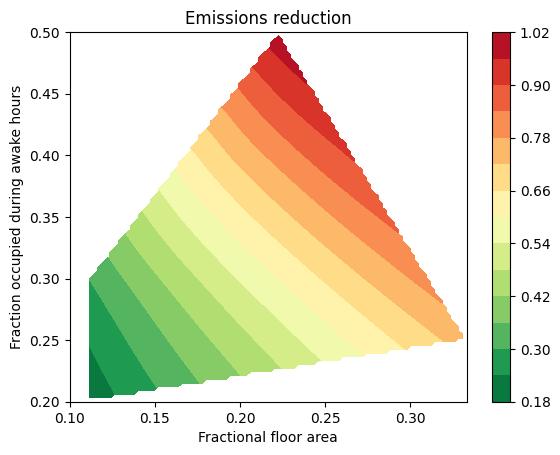

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

points = np.array([(2/9, 0.5), (1/9, 0.2), (2/9, 0.4), (3/9, 0.25), (1/9, 0.3)])
values = np.array([1, 0.2, 0.8, 0.75, 0.3])

grid_x, grid_y = np.mgrid[0.1:0.3333:100j, 0.2:0.5:100j]
grid_z = griddata(points, values, (grid_x, grid_y), method='cubic')

plt.contourf(grid_x, grid_y, grid_z, levels=14, cmap='RdYlGn_r')
plt.colorbar()
#plt.scatter(points[:, 0], points[:, 1], c='black')
plt.title('Emissions reduction')
plt.xlabel('Fractional floor area')
plt.ylabel('Fraction occupied during awake hours')
plt.show()
